In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

ERROR:2026-09-12 00:19:07,282:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


cpu
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

# compile caching
if device.device_kind != "cpu":
    # if gethostname().startswith("max-"):
    #     jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
    #     jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
    #     jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
    #     jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")

    stats = device.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"]
    print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
    print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
    print(f"Free       : {free / 1024**3:.2f} GB")


if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
epochs = 5000
nn_config = 0
# nn_config = 2
intermediate_prints = []
intermediate_prints = [100, 1000, 3000, 5000, 10000, 15000]
# intermediate_prints = [200, 5000]
# intermediate_prints = [25]
# intermediate_prints = list(range(1000, 19000, 2000))
n_files_per_filt = 1  # max out at 10
n_vals_per_filt = 1  # max out at 5
one_filt_flag = False
cal_flag = True
binary_flag = True
val_flag = True
flat_flag = True
pos1_only = True
static_optics = False
plot_flag = check_script()
# plot_flag = True
save_flag = check_script()
recalculate_flag = False
best_state = load_dict(amigo_files_path + "/final_statev38.npy")
secondary_state = load_dict(amigo_files_path + "/scratch_bfgs_final_state.npy")
# best_state = load_dict(amigo_files_path + "/final_statev27.npy")
# best_state = load_dict(amigo_files_path + "/best_statev26.npy")
best_weights = None
# best_weights = np.load(amigo_files_path + f"/scratch_distill_{nn_config}.npy")


if save_flag:
    try:
        job_index = int(sys.argv[1])
    except:
        pass
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)

    job_name = os.environ.get("SLURM_JOB_NAME")
    if job_name is not None:
        job_id = "_".join([job_id, job_name])
    
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None


print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-cpuv3-0-24
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


In [3]:
from retrain_fns import summarise_files
import importlib

resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")

with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)

# # Add extra bad pixels
# badpix = np.load(f"{cache_dir}/full_badpix.npy")
# # badpix = np.load(f"{cache_dir}/full_badpix.npy")
# badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    # if file[0].header["PROGRAM"] == "04481" and file[0].header["FILTER"] == "F430M":
    #     file["BADPIX"].data[30, 40] = 1
    return file


## Validation files
Calibrators from other science programs

In [4]:
from amigo.misc import get_pos

def sort_files(files, n):
    files.sort(key=lambda x: (x[0].header["PROGRAM"], x[0].header["FILTER"], x[0].header["PATT_NUM"]), reverse=True)
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}

    for filt in filts:
        if one_filt_flag and filt != "F480M":
            these_files[filt] = []
            continue

        matched = [f for f in files if f[0].header["FILTER"] == filt]

        if pos1_only:
            x = [f for f in matched if get_pos(f) == "POS1"]
        else:
            pos1 = [f for f in matched if get_pos(f) == "POS1"]
            pos2 = [f for f in matched if get_pos(f) == "POS2"]
            x = []
            for a, b in zip(pos1, pos2):
                x.extend([a, b])
            x.extend(pos1[len(pos2):])
            x.extend(pos2[len(pos1):])

        these_files[filt] = x[0:n]

    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

In [5]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []

# Collated validator subset
program_path = os.path.join(data_dir, "VAL_SUBSET/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = sort_files(files, n_vals_per_filt)
val_files += files

# Adding bad pixels and summarising metadata
val_files = [add_badpix(file) for file in val_files]
summarise_files(val_files)

  program     target filter dither     g/i        date              PI   CAL
0    1843  HD-205827  F480M    1/1  10/641  26-10-2022  Kammerer, Jens  True
1    1843  HD-205827  F380M    1/1  3/7800  26-10-2022  Kammerer, Jens  True
2    1843  HD-205827  F430M    1/1  7/1885  26-10-2022  Kammerer, Jens  True


## Calibration files
The main training data, including flats.

In [6]:
calpsf_files = []
calbin_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
calpsf_files += files
calpsf_files = [add_badpix(file) for file in calpsf_files]
calpsf_files = sort_files(calpsf_files, n_files_per_filt)
summarise_files(calpsf_files)

print()
print("CAL8330 - Benjamin Pope")
program_path = os.path.join(data_dir, "8330/calslope/")
files = get_files(program_path, "nis_calslope")
calbin_files += files
calbin_files = [file for file in calbin_files if file[0].header["NGROUPS"] > 3]
calbin_files = [add_badpix(file) for file in calbin_files]
calbin_files = sort_files(calbin_files, n_files_per_filt)
summarise_files(calbin_files)

CAL4481 - Anand Sivaramakrishnan
  program    target filter dither      g/i        date                       PI   CAL
0    4481  HD-41094  F480M    5/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
1    4481  HD-41094  F380M    5/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
2    4481  HD-41094  F430M    5/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True

CAL8330 - Benjamin Pope
  program    target filter dither     g/i        date              PI    CAL
0    8330  V-EZ-Aqr  F480M   5/10  18/220  11-11-2025  Pope, Benjamin  False
1    8330  V-EZ-Aqr  F380M   5/10  11/260  11-11-2025  Pope, Benjamin  False
2    8330  V-EZ-Aqr  F430M   5/10  16/250  11-11-2025  Pope, Benjamin  False


Flats.

In [7]:
flat_files = []
print()
print("FLATS")
program_path = os.path.join(data_dir, "FLATS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_LAMP")
flat_files += files
# flat_files = [file for file in flat_files if file[0].header["NGROUPS"] != 45]
flat_files = sort_files(flat_files, n_files_per_filt)

flat_files = [add_badpix(file) for file in flat_files]
summarise_files(flat_files)


FLATS
  program   target filter dither    g/i        date             PI   CAL
0    1503  UNKNOWN  F380M    1/1  30/10  04-02-2023  Martel, Andre  FLAT
1    1503  UNKNOWN  F480M    1/1  30/10  16-03-2023  Martel, Andre  FLAT


# Exposures

In [8]:
# from amigo.model_fits import PointFit
from retrain_fns import BinaryFit, DarkFit, _PointFit

class UniqueAbPointFit(_PointFit):
    def get_key(self, param):
        match param:
            case "aberrations":
                return "_".join((self.filter, self.key))
        return super().get_key(param)

In [9]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit, DarkFit

# Construct the exposures
calpsf_exposures = [_PointFit(file) for file in calpsf_files] if cal_flag else []
calbin_exposures = [BinaryFit(file) for file in calbin_files] if binary_flag else []
val_exposures = [UniqueAbPointFit(file) for file in val_files] if val_flag else []
flat_exposures = [FlatFit(file) for file in flat_files] if flat_flag else []
# dark_exposures = [DarkFit(file) for file in dark_files]

cal_exposures = calpsf_exposures + calbin_exposures
exposures = cal_exposures + val_exposures + flat_exposures
print(f"Total number of exposures: {len(exposures)}")

# just closing the files
files = calpsf_files + calbin_files + val_files + flat_files# + dark_files
_ = [f.close() for f in files]

Total number of exposures: 11


Finally, let's batch the exposures for training.

In [10]:
from amigo.fitting import batch_exposures

bs = 3
# bs = 1 if one_filt_flag else 3

# Get the batches: Calibrator, flats, and validators
cal_batch = batch_exposures(cal_exposures, batch_size=bs, key="cal")
flat_batch = batch_exposures(flat_exposures, batch_size=bs, key="flat")
val_batch = batch_exposures(val_exposures, batch_size=bs, key="val")
# dark_batch = batch_exposures(dark_exposures, batch_size=bs, key="dark")
nn_batches = {**cal_batch, **flat_batch}

# Building model

In [11]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from retrain_fns import nn_setup_options

nn_arch = nn_setup_options[nn_config]
# nn_arch = nn_setup_options[2]
# nn_arch = nn_setup_options[job_index]

optics = AMIOptics(
    radial_orders=7,
    static=static_optics,
)

# Get the model
model = AmigoModel(
    exposures=exposures,
    # optics=AMIOptics(),
    optics=optics,
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(**nn_arch),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)
print(nn_arch, model.nn_weights.shape)

{'hidden_width': 16, 'n_hidden_layers': 3} (8640,)


Populate from state.

In [12]:
state = load_dict(amigo_files_path + "/calibration.npy")

def update_abs(model, ab_dict):
    ab_shape = list(model.get("aberrations").values())[0].shape
    state_ab_shape = list(ab_dict.values())[0].shape

    if ab_shape[1] != state_ab_shape[1]:

        if ab_shape[1] > state_ab_shape[1]:
            y = np
            expand_abs = lambda x: np.concatenate((x, np.zeros((ab_shape[0], ab_shape[1] - state_ab_shape[1]))), axis=1)
            ab_dict = jax.tree.map(expand_abs, ab_dict)
        else:
            raise NotImplementedError()
    return model.set("aberrations", ab_dict)

if "jitter" in state.keys():
    state["sigma"] = state["jitter"]
    del state["jitter"]
    
for key, value in state.items():
    if key == "transmission" and not static_optics:
        continue
    if key in ["primary_beam", "distortion"] and static_optics:
        continue
    if key in [
        'aberrations',
        # 'primary_beam',
        # 'distortion',
        # 'transmission',
        'badpix',
    ]:
        continue
    model = model.set(key, value)

if cal_flag or binary_flag:
    ab_dict = {}
    for key, _ in model.aberrations.items():
        try:
            prog, filt = key.split("_")
        except ValueError:
            ids = key.split("_")
            if len(ids) > 1:
                filt = ids[0]
            else:
                filt = "F430M"
        try:        
            ab_dict[key] = state["aberrations"][filt]
        except KeyError:
            ab_dict[key] = state["aberrations"]["F430M"]

    model = update_abs(model, ab_dict)
            
print()
for key, value in best_state.items():
    if key in [
        'positions',
        'flat_coeffs',
        'fluxes',
        'pas',
        'separations',
        'contrasts',
        # 'aberrations',
        'nn_weights',
        'primary_beam',
        'distortion',
        'FF',
        'non_linearity',
        'sigma',
        'defocus',
        'dark_current',
    ]:

            
        if key in model.params.keys():
            # model = model.set(key, value)
            default = model.get(key)
            model = model.set(key, default | value)
        else:
            # pass
            model = model.set(key, value)

    if key == "aberrations":
        # pass
        model = update_abs(model, value)

# for key, val in secondary_state.items():
#     if key == "aberrations":
#         val["08330_F380M"] = val.pop('F380M_08330_002_04_03_5')
#         val["08330_F430M"] = val.pop('F430M_08330_002_06_03_5')
#         val["08330_F480M"] = val.pop('F480M_08330_002_02_03_5')

#     model_param = model.get(key)

#     this_param = {k: val.get(k, v) for k, v in model_param.items()}
#     model = model.set(key, this_param)

# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.0
ff = ff.at[badpix].set(1.0)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

if cal_flag:
    spec_dic = model.spectra
    spec_dic["HD-41094_F380M"] = np.array(-0.12454516)
    spec_dic["HD-41094_F430M"] = np.array(-0.14548536)
    spec_dic["HD-41094_F480M"] = np.array(-0.12436274)
    model = model.set("spectra", spec_dic)
                                          
if binary_flag:
    # for exp in calbin_exposures:
        # model = model.set(
        #     exp.map_param("pas"),
        #     np.array(66.31),
        # )
        # model = model.set(
        #     exp.map_param("separations"),
        #     np.array(0.1259),
        # )
        # model = model.set(
        #     exp.map_param("contrasts"),
        #     np.array(0.376),
        # )
    spec_dic = model.spectra
    spec_dic["V-EZ-Aqr_F380M"] = np.array([-0.07376706, -0.07606107])
    spec_dic["V-EZ-Aqr_F430M"] = np.array([-0.14906244, -0.14530317])
    spec_dic["V-EZ-Aqr_F480M"] = np.array([-0.12971859, -0.12976371])
    model = model.set("spectra", spec_dic)

if best_weights is not None:
    model = model.set("nn_weights", best_weights)

## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

In [13]:
from amigo.plotting import summarise_fit

if plot_flag and (cal_flag or binary_flag):
    if save_flag:
        this_save_path = os.path.join(save_path, "init_cal")
        os.mkdir(this_save_path)
    else:
        this_save_path = None
    for exp in cal_exposures:
        exp.print_summary()
        # try:
        summarise_fit(model, exp, save_path=this_save_path, top_group=False)
        # except Exception as e:
            # print(f"Plotting failed: {e}")
            # pass

Now the validator exposures.

In [14]:
if plot_flag:
    if val_flag:
        if save_flag:
            this_save_path = os.path.join(save_path, "init_val")
            os.mkdir(this_save_path)
        else:
            this_save_path = None
        for exp in val_exposures:
            print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints, exp.filename)
            summarise_fit(model, exp, save_path=this_save_path)

Finally, the flats and darks.

In [15]:
if plot_flag:
    if flat_flag:
        if save_flag:
            this_save_path = os.path.join(save_path, "init_flat")
            os.mkdir(this_save_path)
        else:
            this_save_path = None
        for exp in flat_exposures:
            print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
            summarise_fit(model, exp, save_path=this_save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [16]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    # grads_fn,
    aux_fn,
    ff_reg,
    nl_reg,
    sep_reg,
    pa_reg,
    linear_reg,
    temp_decay,
    cosine_warmup,
)

from retrain_fns import get_warmup, get_temperature

binary_ab_keys = [exp.map_param("aberrations") for exp in calbin_exposures]
cal_stars = ["HD-41094", "V-EZ-Aqr"]


def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    # flat field
    if hasattr(model_params, "FF"):
        FF = model_params.FF
        FF -= np.median(FF) - 1.0
        FF = FF.at[badpix].set(1.0)
        model_params = model_params.set("FF", FF)

    # # dark current
    # if hasattr(model_params, "dark_current"):
    #     DC = model_params.dark_current
    #     DC = DC.at[badpix].set(np.median(DC))
    #     model_params = model_params.set("dark_current", DC)

    # non linearity
    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    # spectra clipping
    if hasattr(model_params, "spectra"):
        spectra = model_params.spectra
        clip_fn = lambda x: np.clip(x, a_min=-0.8, a_max=0.8)
        spectra = jax.tree.map(clip_fn, spectra)
        model_params = model_params.set("spectra", spectra)

    return model_params, args


def grads_fn(model, grads, args):

    # Get the parameters
    grad_params = grads.params

    if "spectra" in grad_params.keys():
        for key, val in grad_params["spectra"].items():
            for star in cal_stars:
                if star in key:
                    val = jax.tree.map(lambda x: 0*x, val)
                    grad_params["spectra"][key] = val

    # if "aberrations" in grad_params.keys():
    #     grads = grads.multiply(binary_ab_keys, 1.0e2)

    
    if "nn_weights" not in grad_params.keys():
        return grads, args

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    values = grad_params["nn_weights"]
    temp = get_temperature(args)
    rand_vals = temp * jr.normal(key, values.shape)
    values += rand_vals

    # Add the learning rate warm-up (we also warm up the temperature here)
    values *= args["max_lr"] * get_warmup(args)

    # Increment the t parameter
    args["t"] += 1.0 / args["n_batch"]

    grad_params["nn_weights"] = values
    grads = grads.set("params", grad_params)

    return grads, args

    
# REGULARISATION
reg_dict = {
    "FF": (1.0, ff_reg),
    "NL": (1.0, nl_reg),
    # "PA": (1.0, sep_reg),
    # "SEP": (1.0, pa_reg),
    # "LIN": (10.0, linear_reg),
}

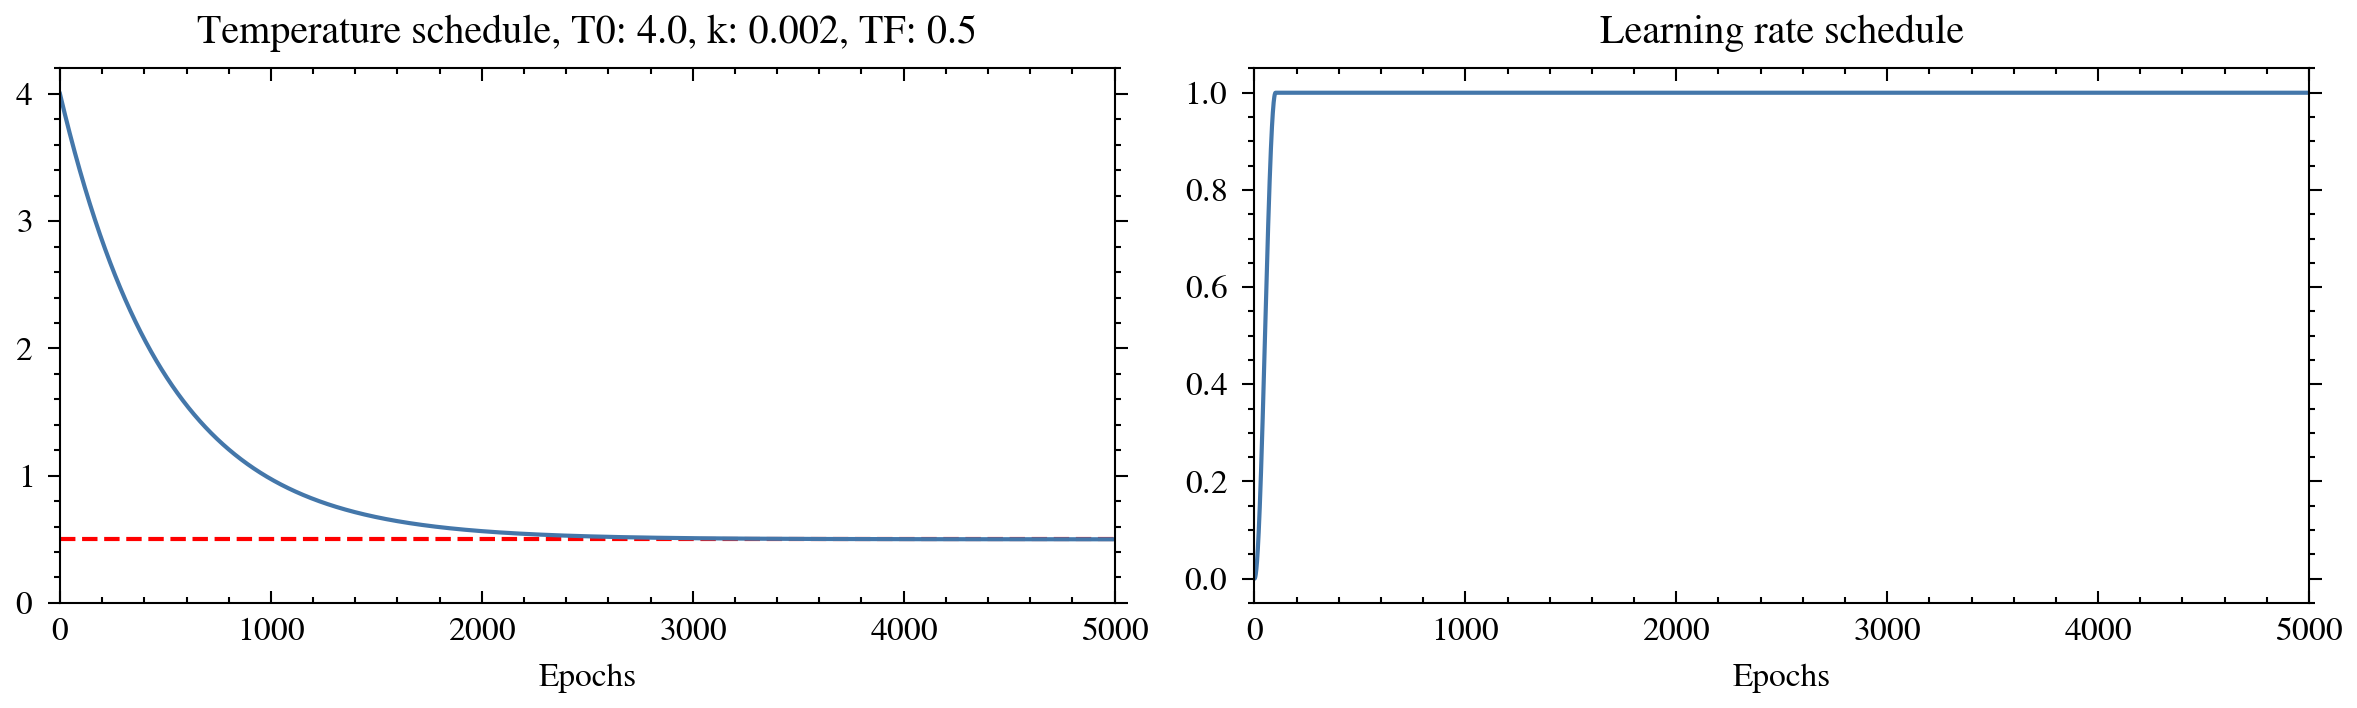

In [17]:
n_batch = len(nn_batches)

# WARM UP
max_lr = 1.  # Learning rate after warm up
t0 = 0  # Warm-up start
n_max = 100  # Warm-up end

# TEMPERATURE DECAY
T0 = 4e0  # Initial temperature
TF = 2e0  # Final temperature
# T0 = 1e-6  # Initial temperature
# decay = 1e-10  # Decay rate of the temperature
decay = 2e-3  # Decay rate of the temperature

args = {
    "n_batch": np.array(n_batch, float),  # Number of batches
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "T0": np.array(T0),  # Initial temperature
    "TF": np.array(TF),  # Final temperature
    "k": np.array(decay),  # Decay rate
    "t0": np.array(t0),  # Warm-up start
    "n_max": np.array(n_max),  # Warm-up end point
    "l2": np.array(0.0),
    "max_lr": np.array(max_lr),  # Learning rate after warm up
    "reg_dict": reg_dict,
}

ts = np.arange(epochs)
temps = temp_decay(t=ts, T0=args["T0"], k=args["k"], TF=args["TF"])
lrs = cosine_warmup(ts, args["t0"], args["n_max"])
l2s = 0 * cosine_warmup(ts, 0, 1000)
args = {**args, **{"l2_schedule": l2s}}


fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
ax[0].set(title=f"Temperature schedule, T0: {args["T0"]}, k: {args["k"]}, TF: {args["TF"]}", xlabel="Epochs", ylim=(0, 1.05*T0), xlim=(0, epochs))
ax[0].axhline(TF, linestyle='--', color="red")
ax[0].plot(ts, temps, label="Temperature")
ax[1].set(title="Learning rate schedule", xlabel="Epochs", xlim=(0, epochs))
ax[1].plot(ts, lrs, label="Learning rate")

plt.tight_layout()
if save_flag:
    plt.savefig(os.path.join(save_path, "schedules.png"), dpi=200)
    plt.close()
else:
    plt.show()

Instantiating trainer class and updating fishers.

In [ ]:
from amigo.calibration import ValBatchedTrainer, BatchedTrainer, Trainer  # , looper_fn, aux_fn
# from dorito.stats import apply_regularisers
from retrain_fns import summarise_fn

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
trainer_class = ValBatchedTrainer if val_flag else Trainer

trainer_class_kwargs = {
    "loss_fn": loss_fn,
    "args_fn": args_fn,
    "grad_fn": grads_fn,
    "norm_fn": norm_fn,
    "summarise_fn": summarise_fn,
    "intermediate_prints": intermediate_prints,
    "save_path": save_path,
    "cache": cache_dir,
}

if val_flag:
    trainer_class_kwargs["aux_fn"] = aux_fn
    trainer_class_kwargs["looper_fn"] = looper_fn   

trainer = trainer_class(**trainer_class_kwargs)

# TODO should there be all the detector parameters here?
if flat_flag:
    print("Flat exposures")
    trainer = trainer.update_fishers(
        linear_model,
        flat_exposures,
        parameters=["flat_coeffs", "fluxes"],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

if val_flag:
    print("Val exposures")
    trainer = trainer.update_fishers(
        linear_model,
        val_exposures,
        batch_size=10,
        parameters=["positions", "aberrations", "fluxes", "spectra"],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

if cal_flag or binary_flag:
    print("Batched cal")
    ps = ["aberrations", "defocus"]
    if not static_optics:
        ps += ["distortion", "primary_beam"]
        # ps += ["distortions", "primary_beams"]
    trainer = trainer.update_fishers(
        linear_model,
        cal_exposures,
        batch_size=10,
        parameters=ps,
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

    print("Unbatched cal")
    trainer = trainer.update_fishers(
        linear_model,
        cal_exposures,
        parameters=[
            "positions",
            "fluxes",
            "spectra",
            "sigma",  # formerly jitter
            "dark_current",
        ],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )
    
    if binary_flag:
        print("Binary Exposures")
        trainer = trainer.update_fishers(
            linear_model,
            calbin_exposures,
            parameters=[
                "pas",
                "separations",
                "contrasts",
            ],
            recalculate=recalculate_flag,
            overwrite=recalculate_flag,
        )

Flat exposures


  0%|          | 0/2 [00:00<?, ?it/s]

Val exposures


  0%|          | 0/3 [00:00<?, ?it/s]

/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1164: UserWarning: A large amount of constants were captured during lowering (2.94GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)
/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1164: UserWarning: A large amount of constants were captured during lowering (2.94GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)
/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1164: UserWarning: A large amount of constants were captured during loweri

Training.

dict_keys(['fluxes', 'positions', 'aberrations', 'pas', 'separations', 'contrasts', 'distortion', 'primary_beam'])


  0%|          | 0/1000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling update function...

Initial_loss Loss: 3,045.42
Estimated run time: 1:09:02
Full Time: 0:05:52
Final Loss: 852.87
Saving best state failed: 'Result' object has no attribute 'best_state'


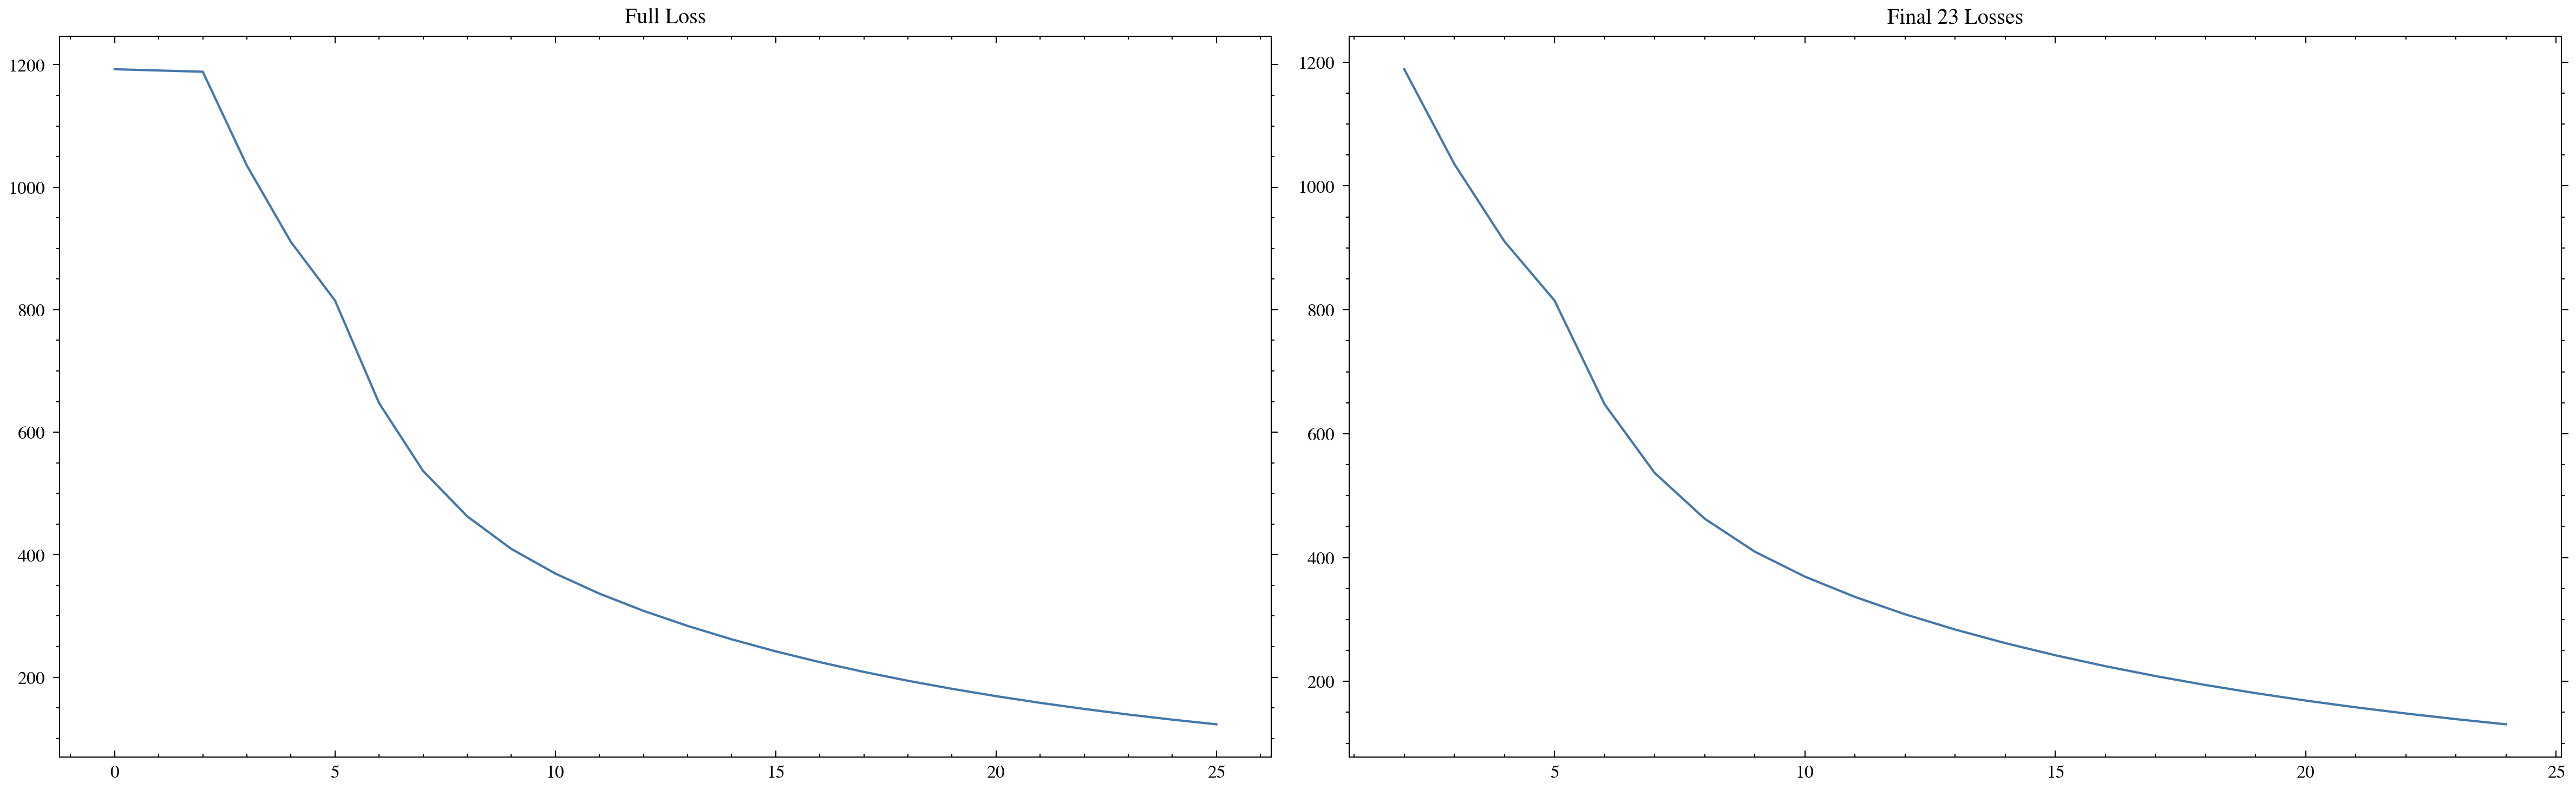

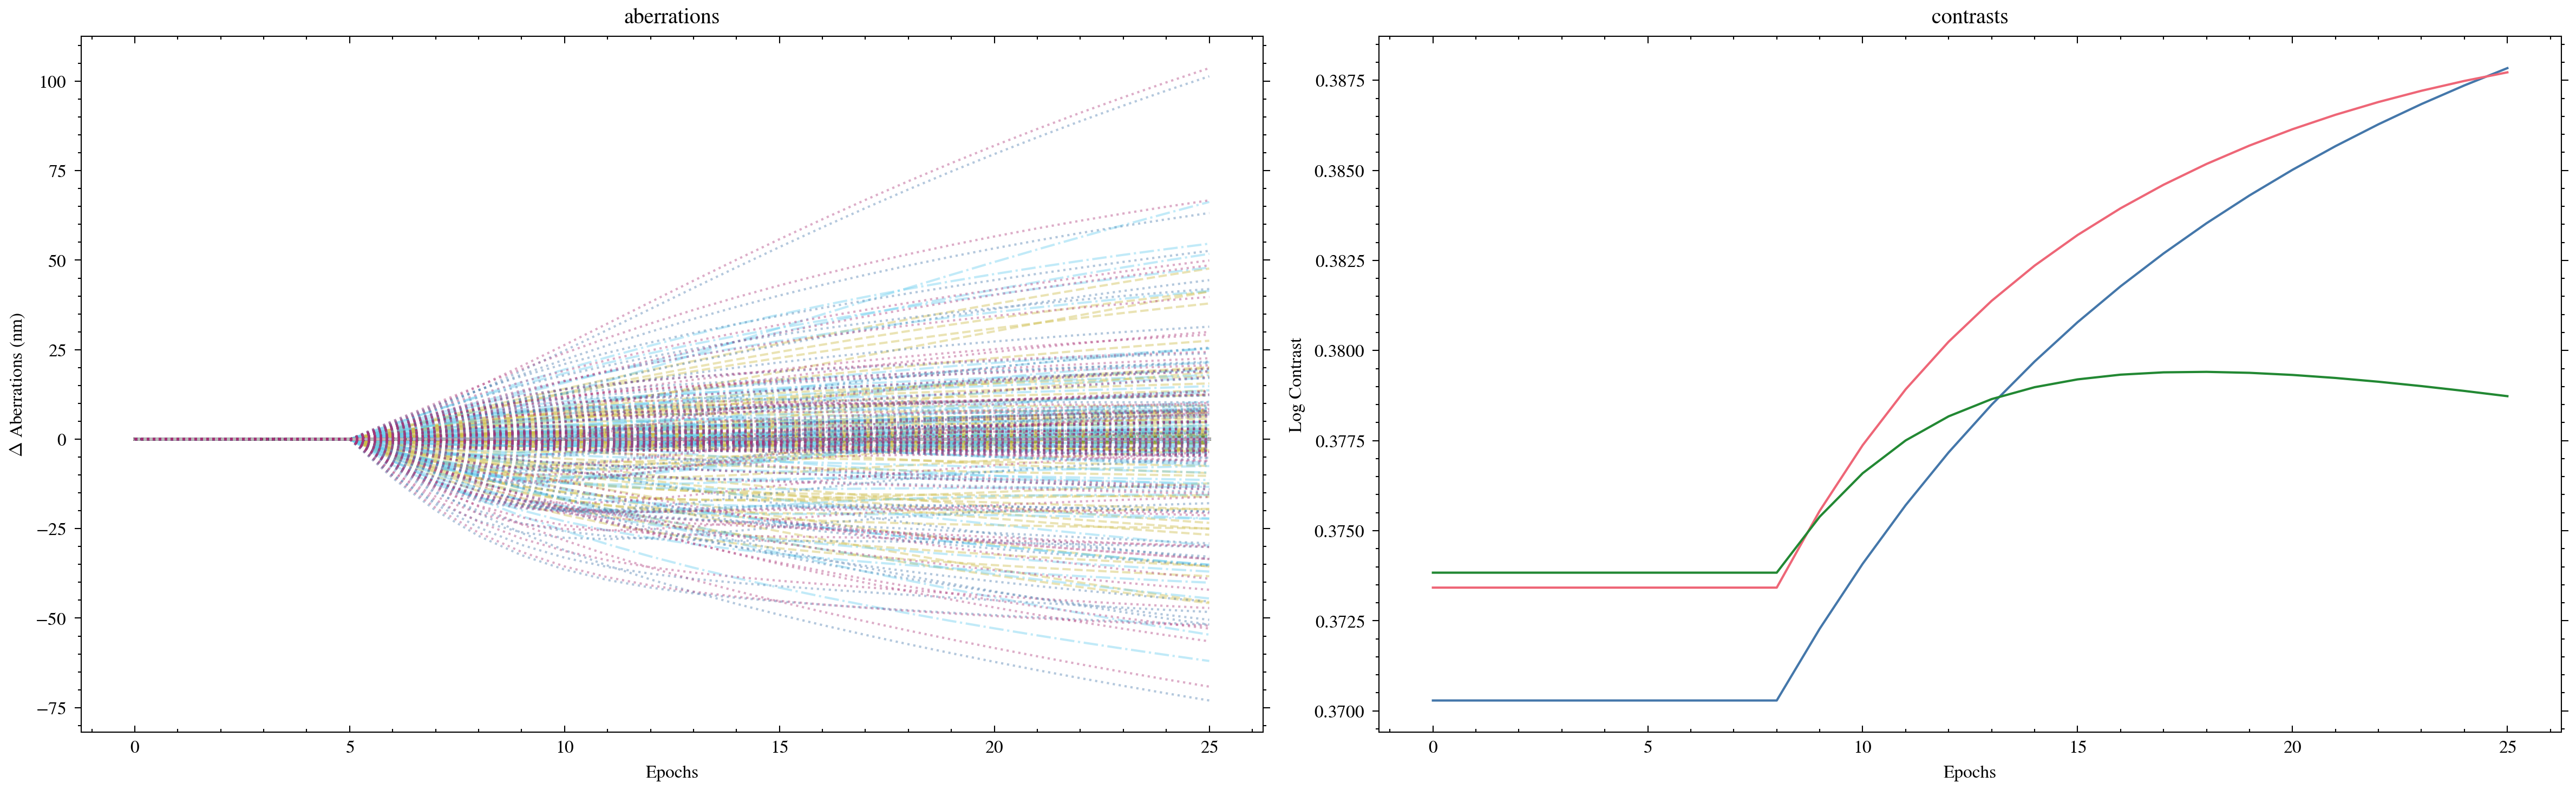

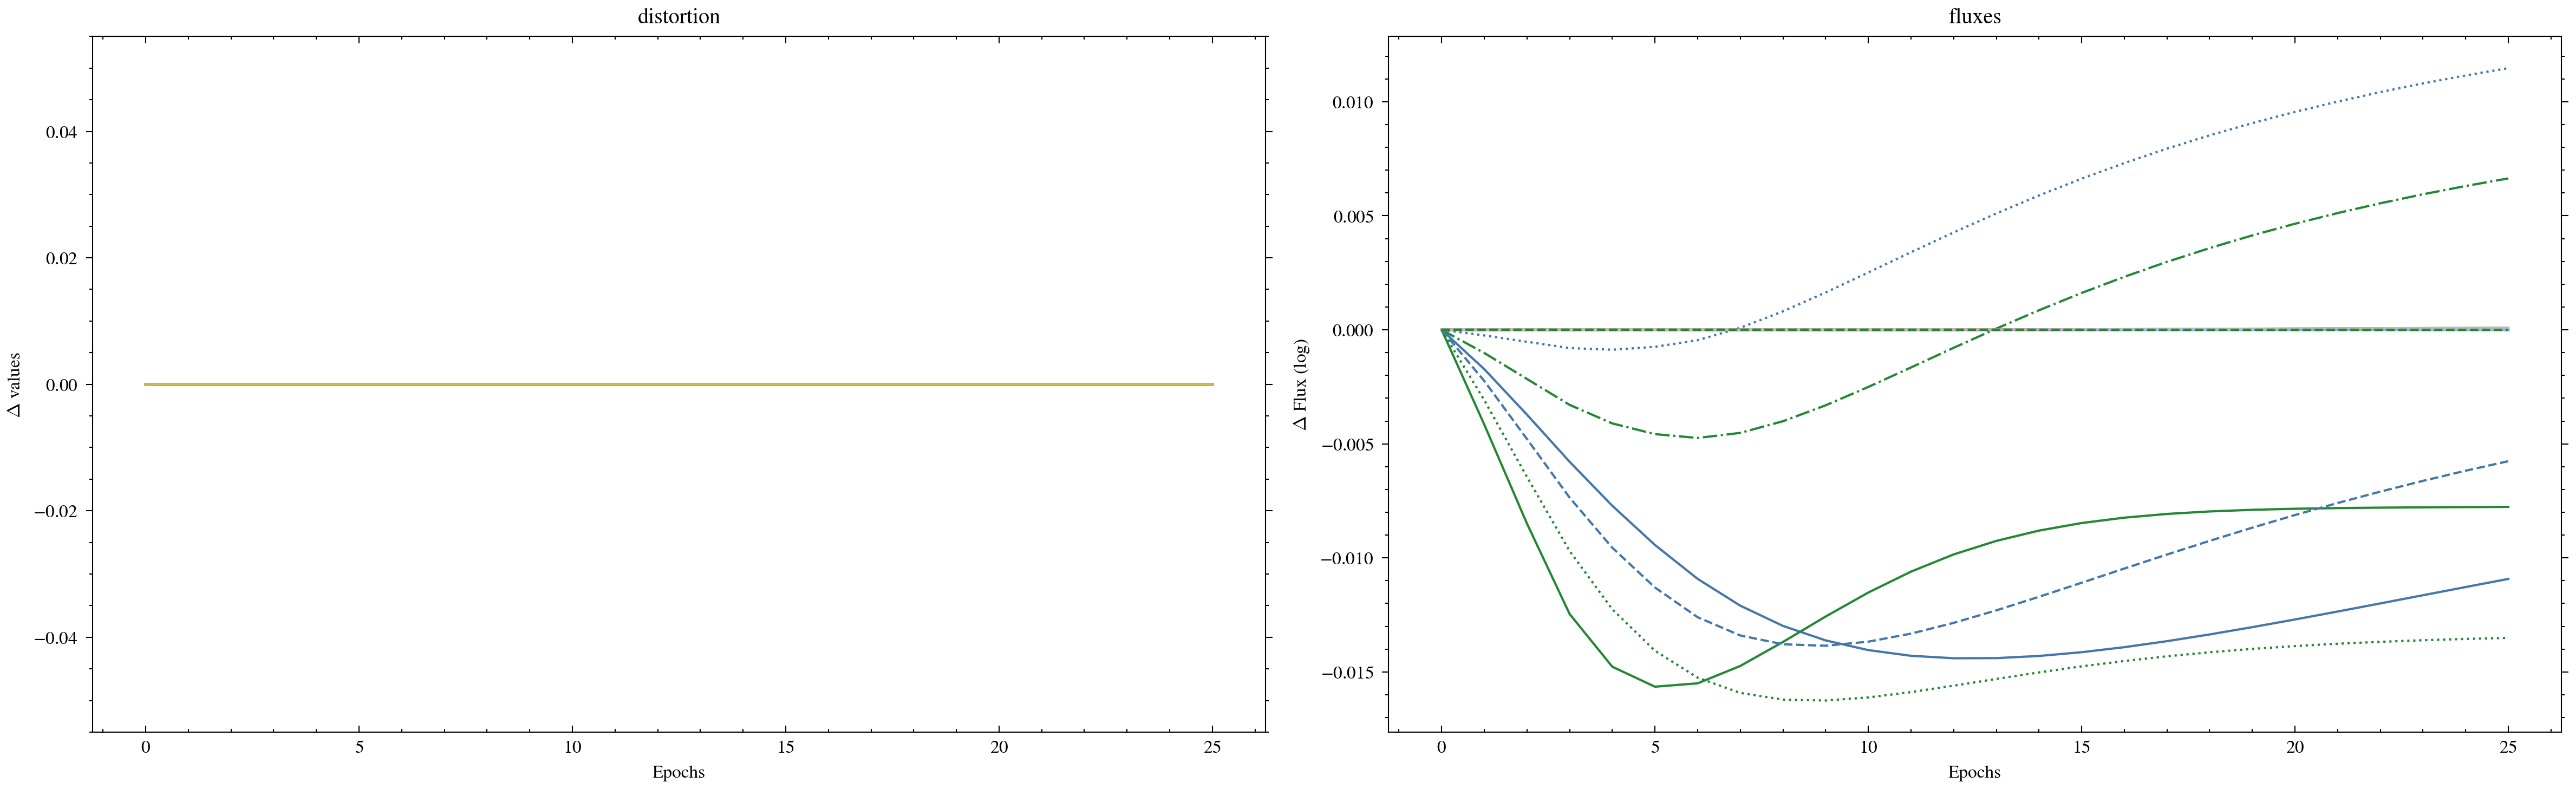

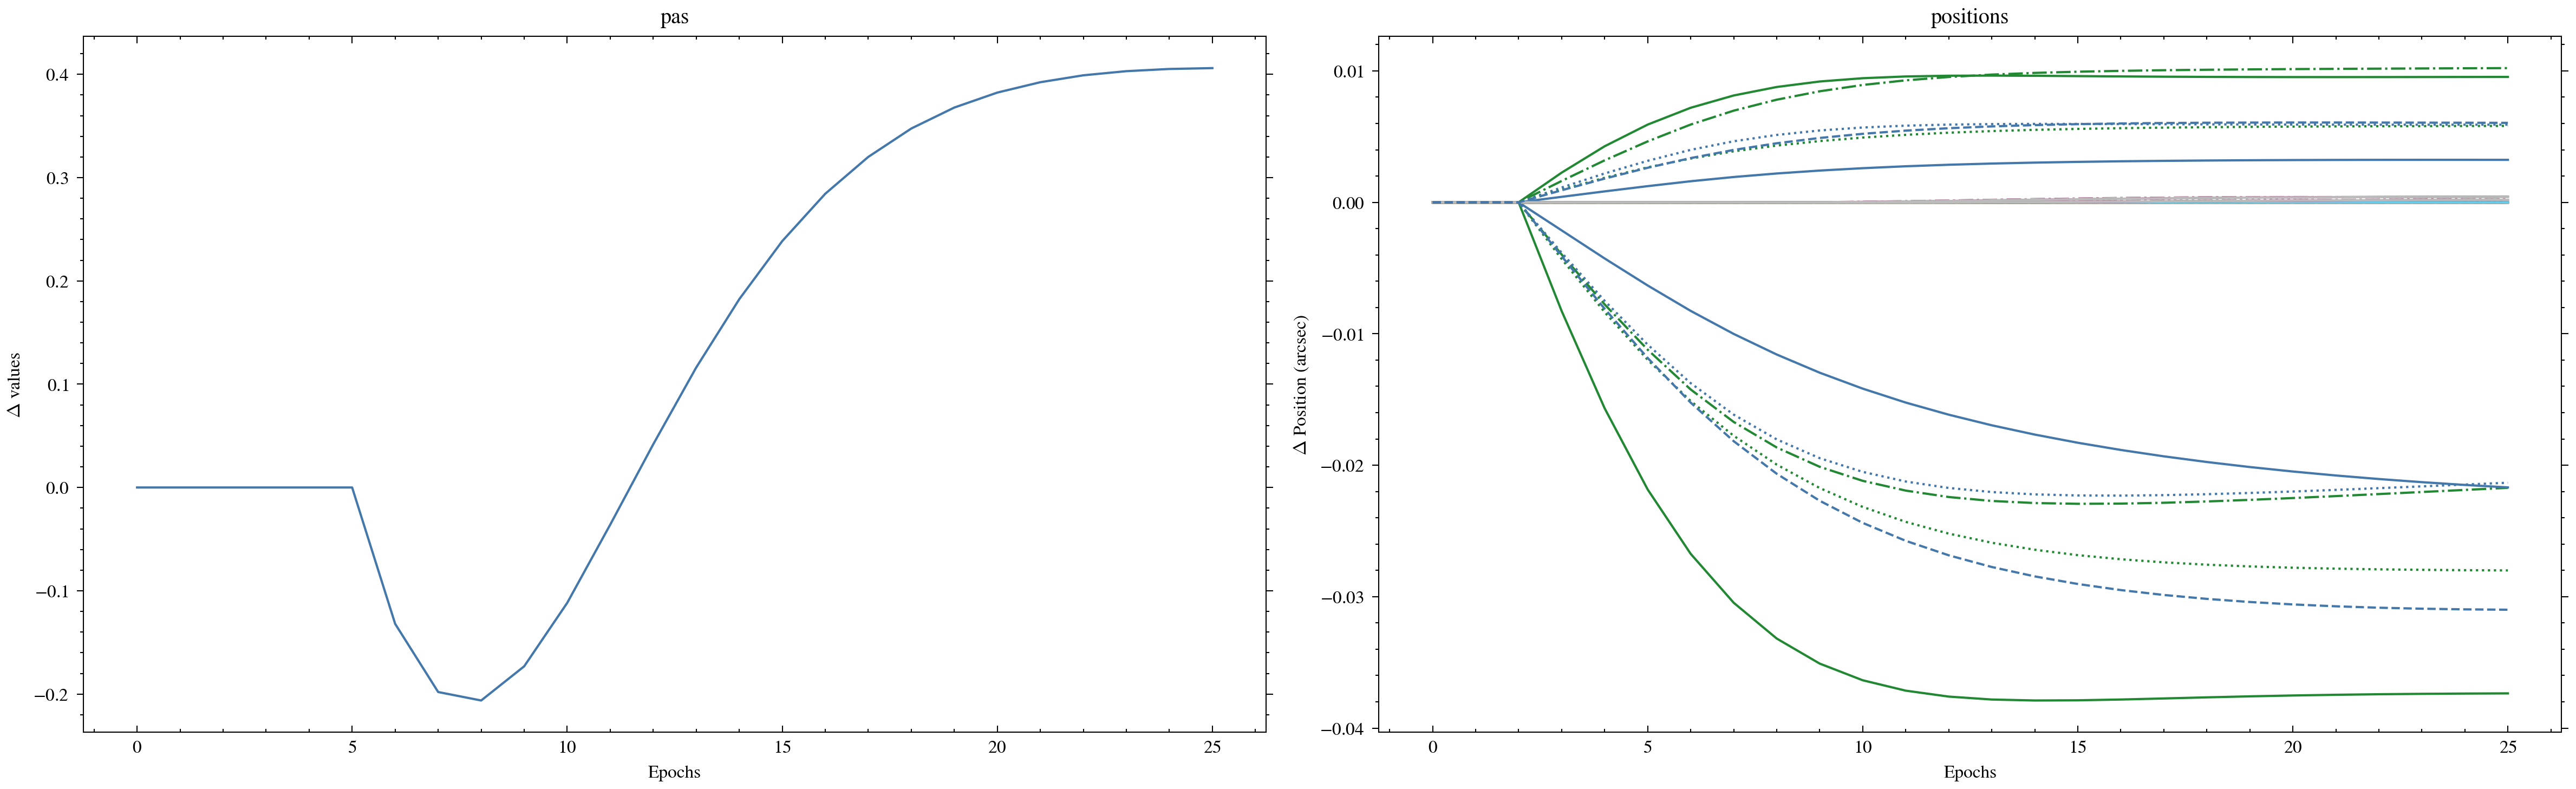

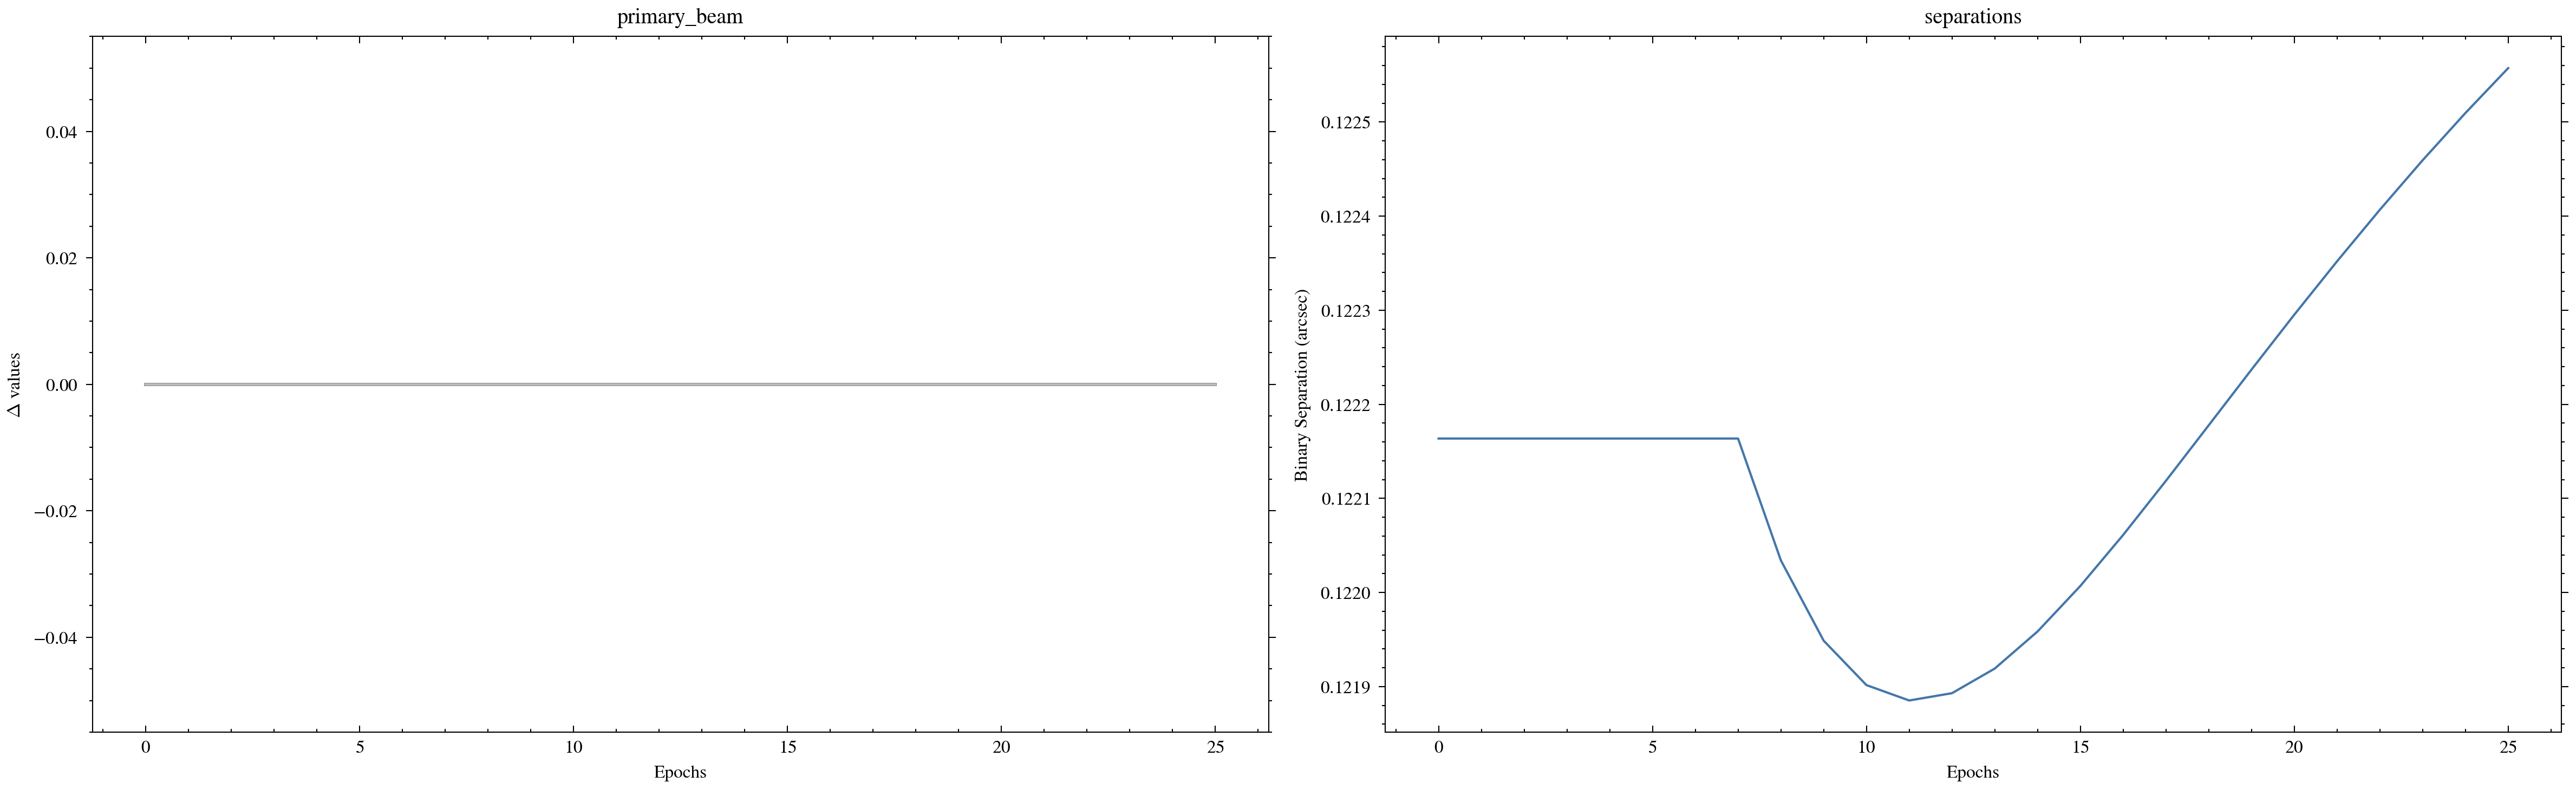







cal
File 08330_002_02_03_5
Star V-EZ-Aqr
Filter F480M
nints 220
ngroups 18



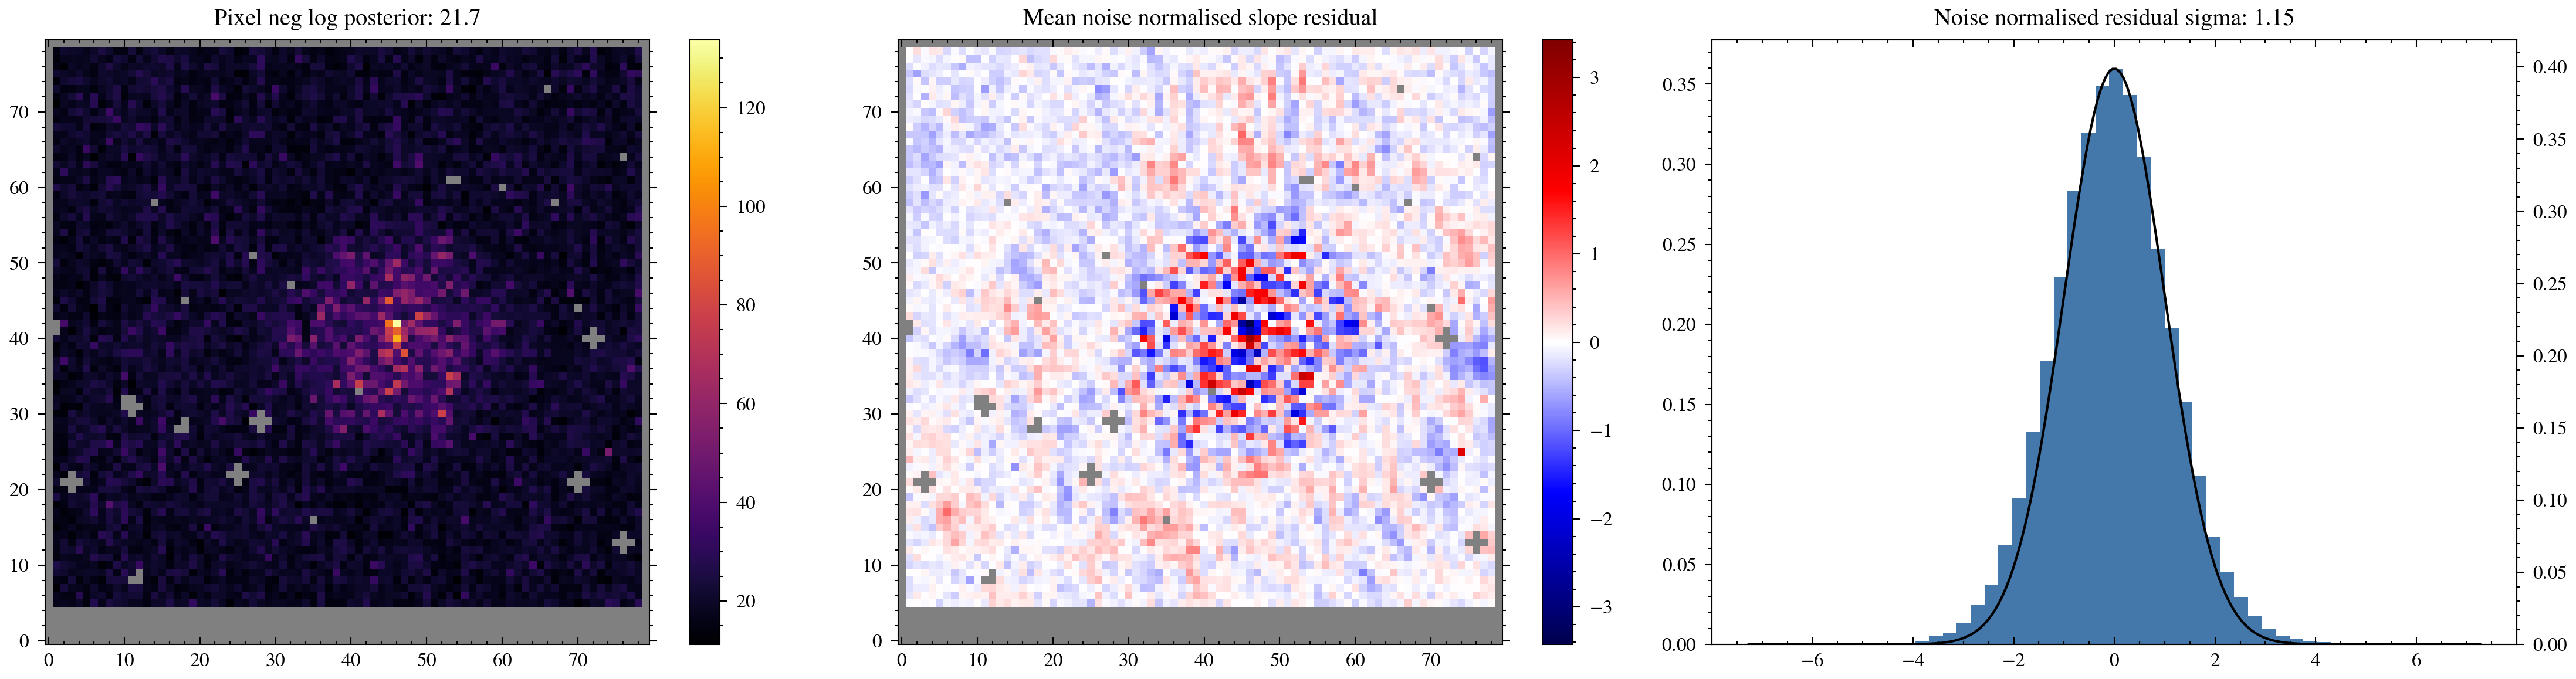

File 08330_002_02_03_10
Star V-EZ-Aqr
Filter F480M
nints 220
ngroups 18



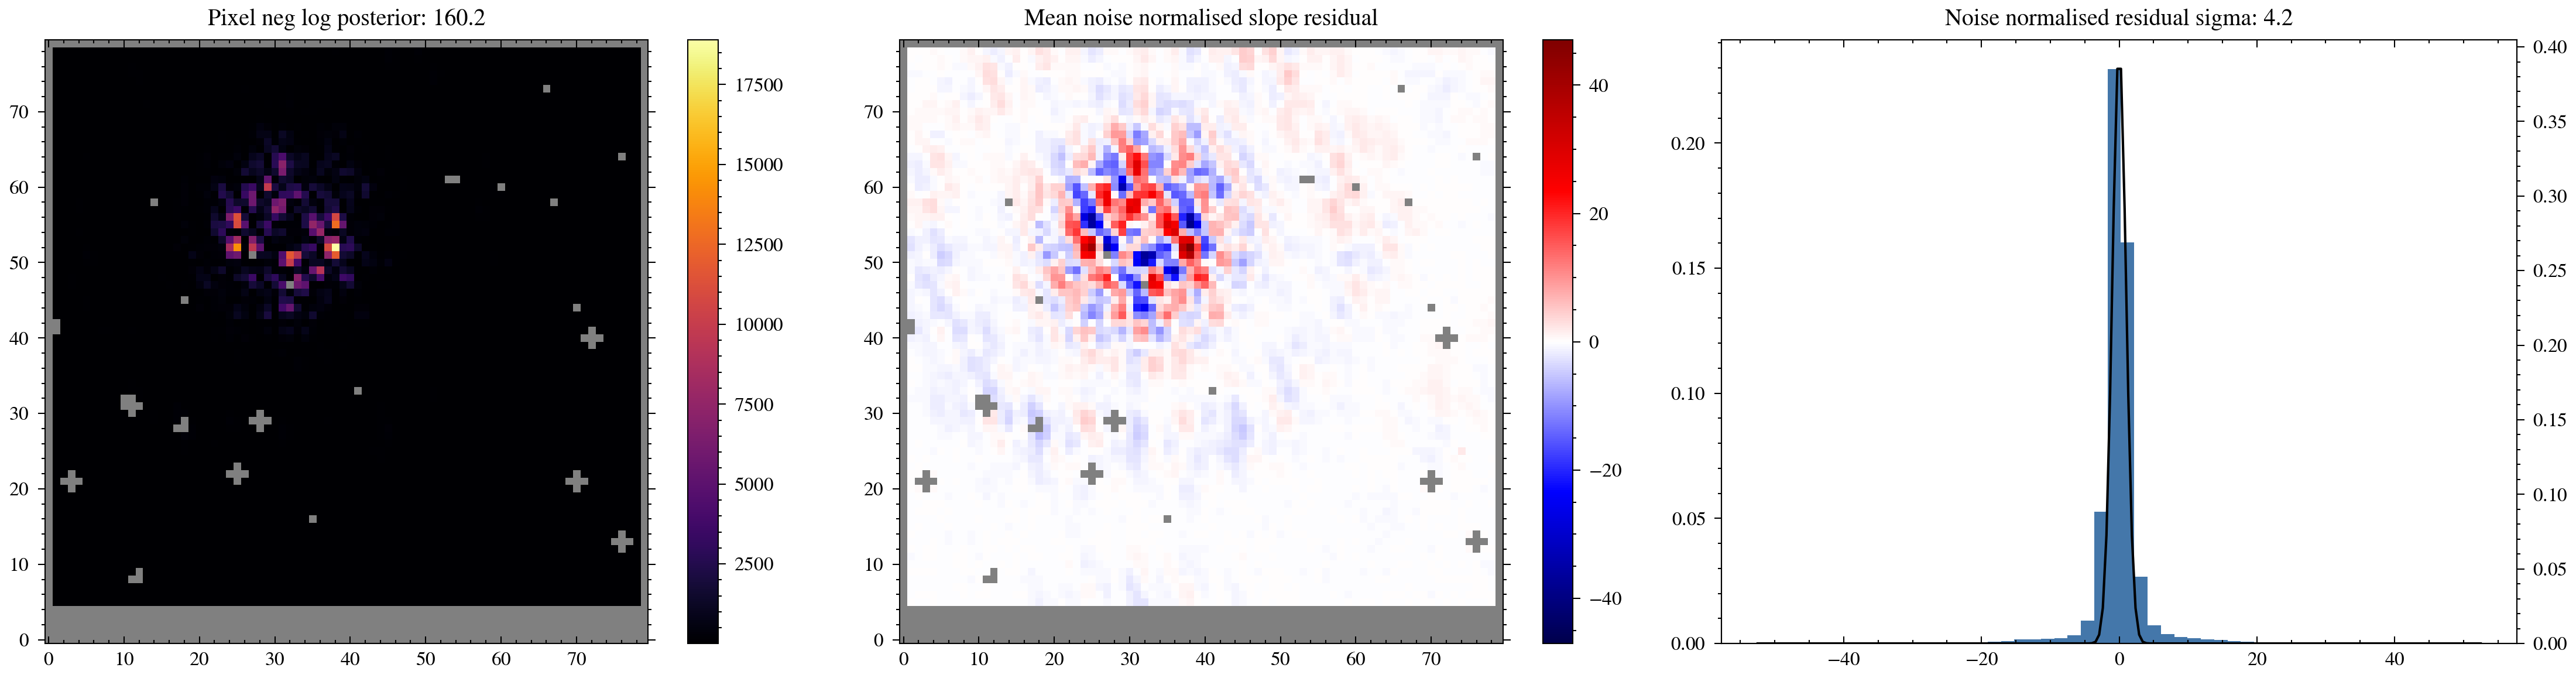

File 08330_002_02_03_4
Star V-EZ-Aqr
Filter F480M
nints 220
ngroups 18



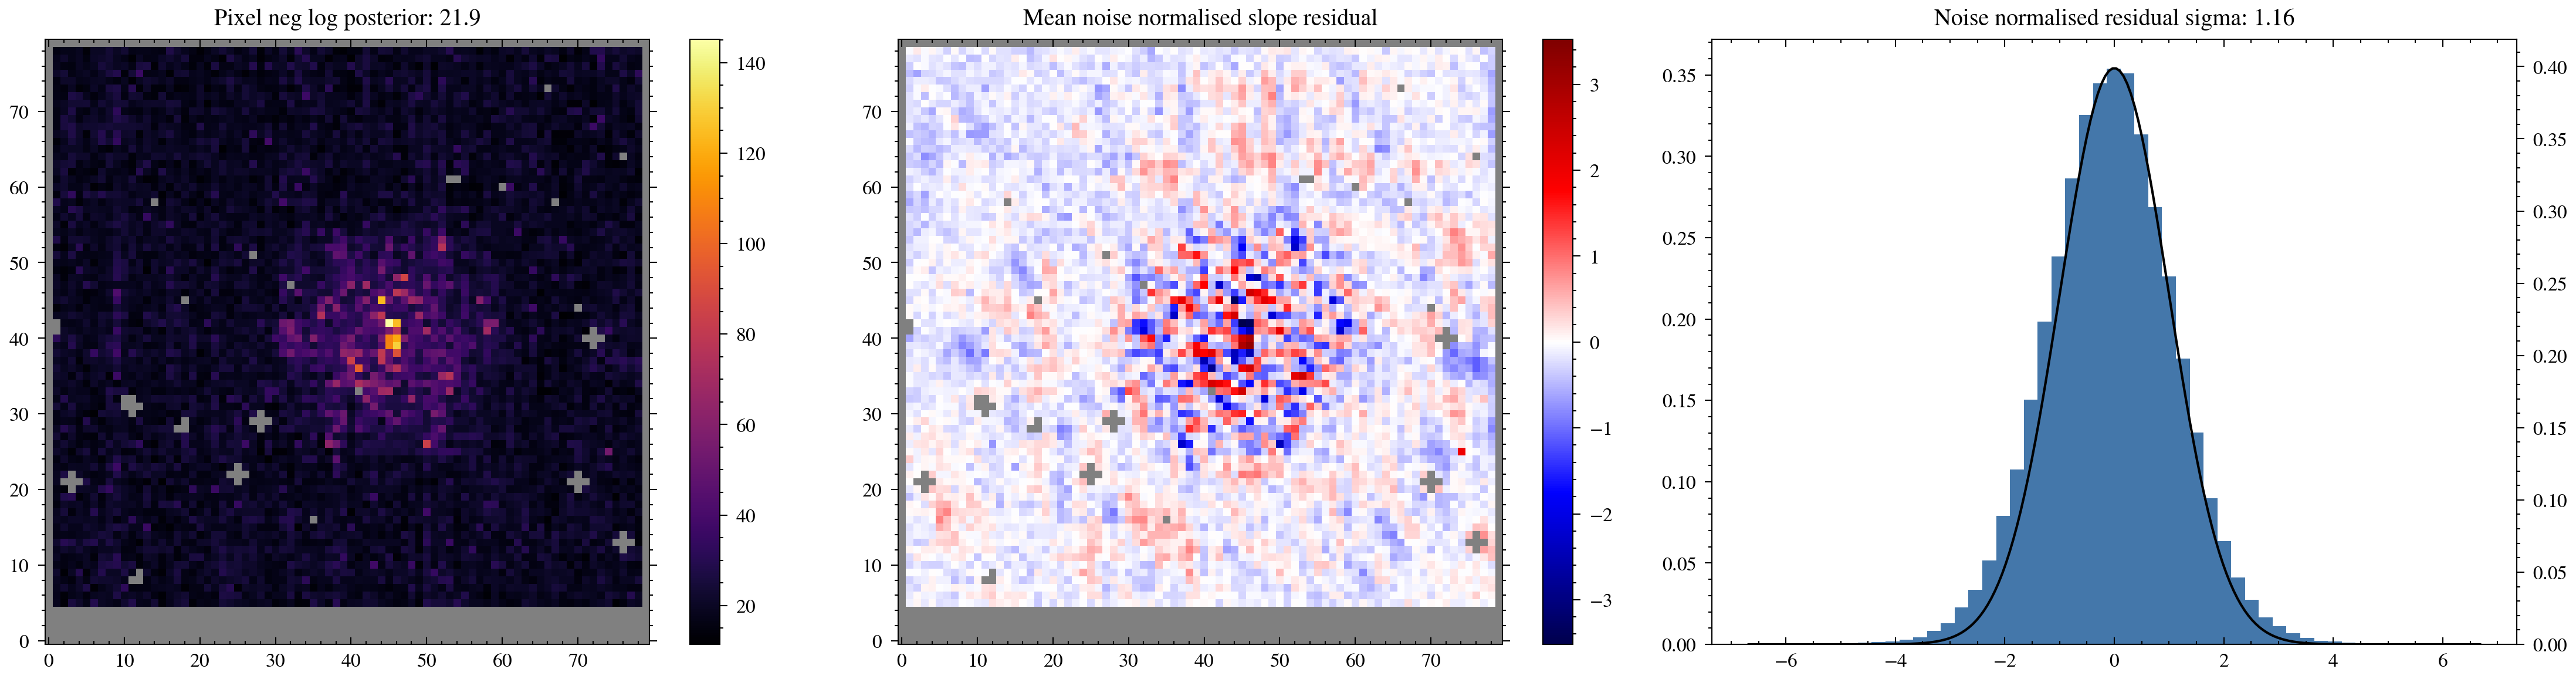

File 08330_002_02_03_9
Star V-EZ-Aqr
Filter F480M
nints 220
ngroups 18



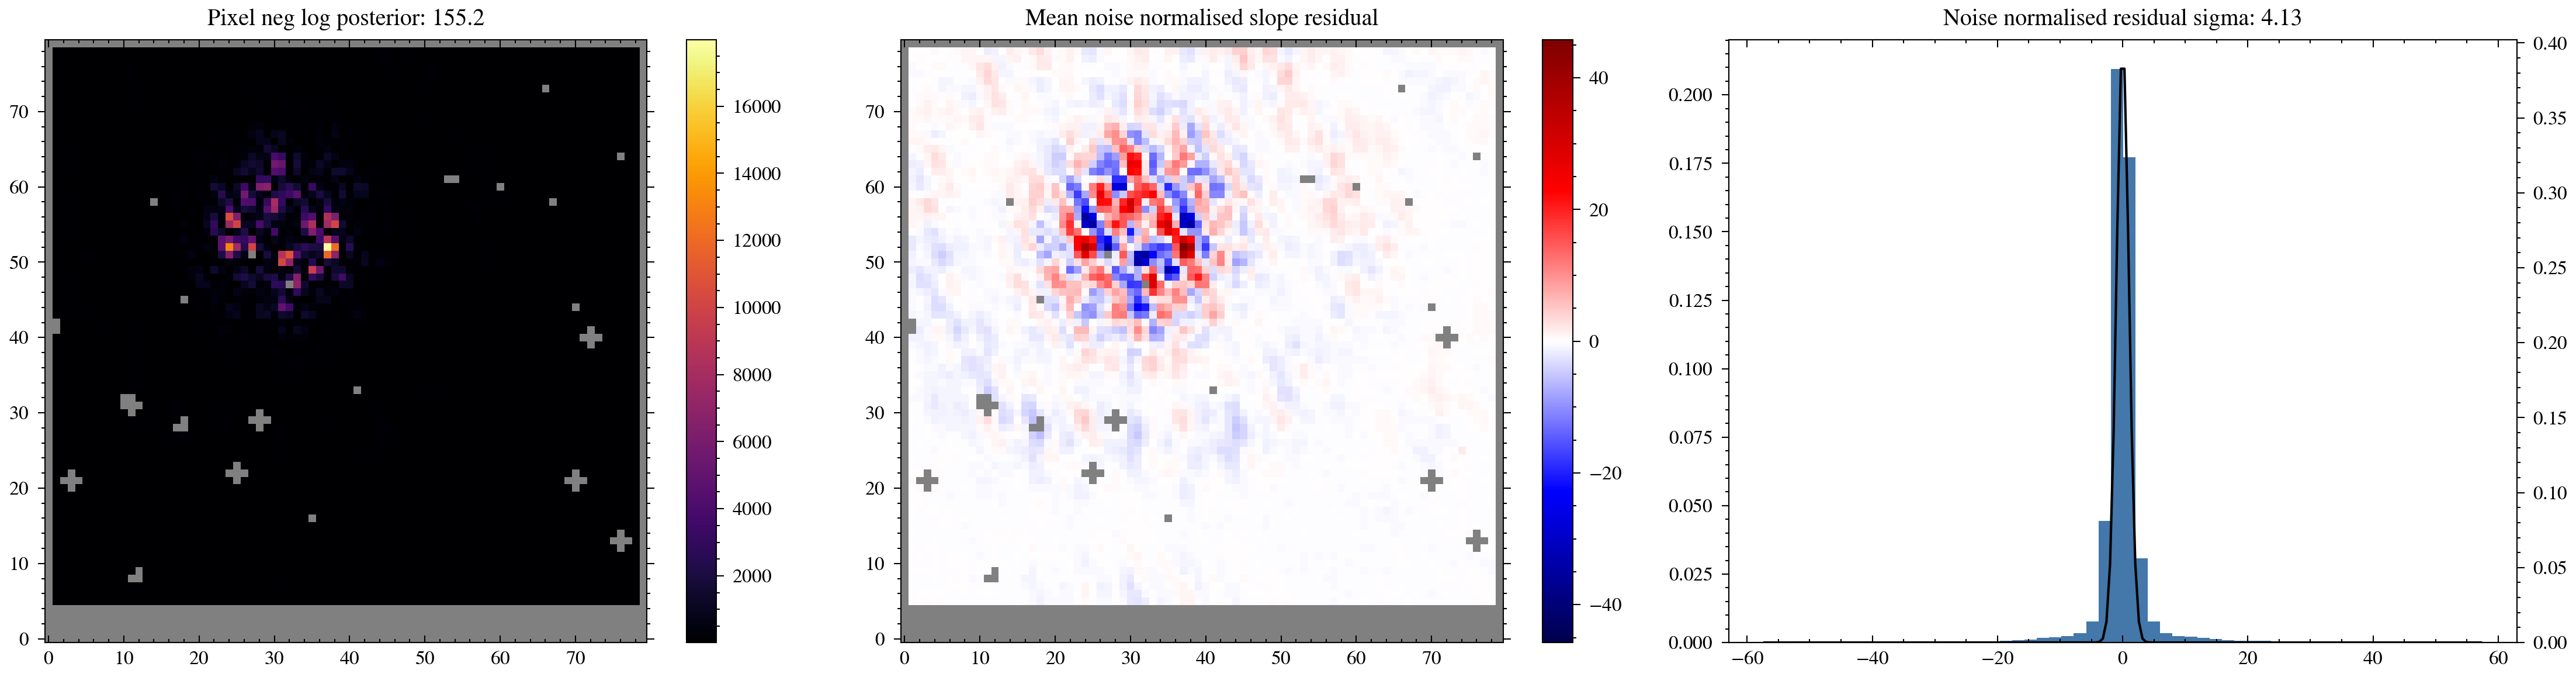

File 08330_002_06_03_5
Star V-EZ-Aqr
Filter F430M
nints 250
ngroups 16



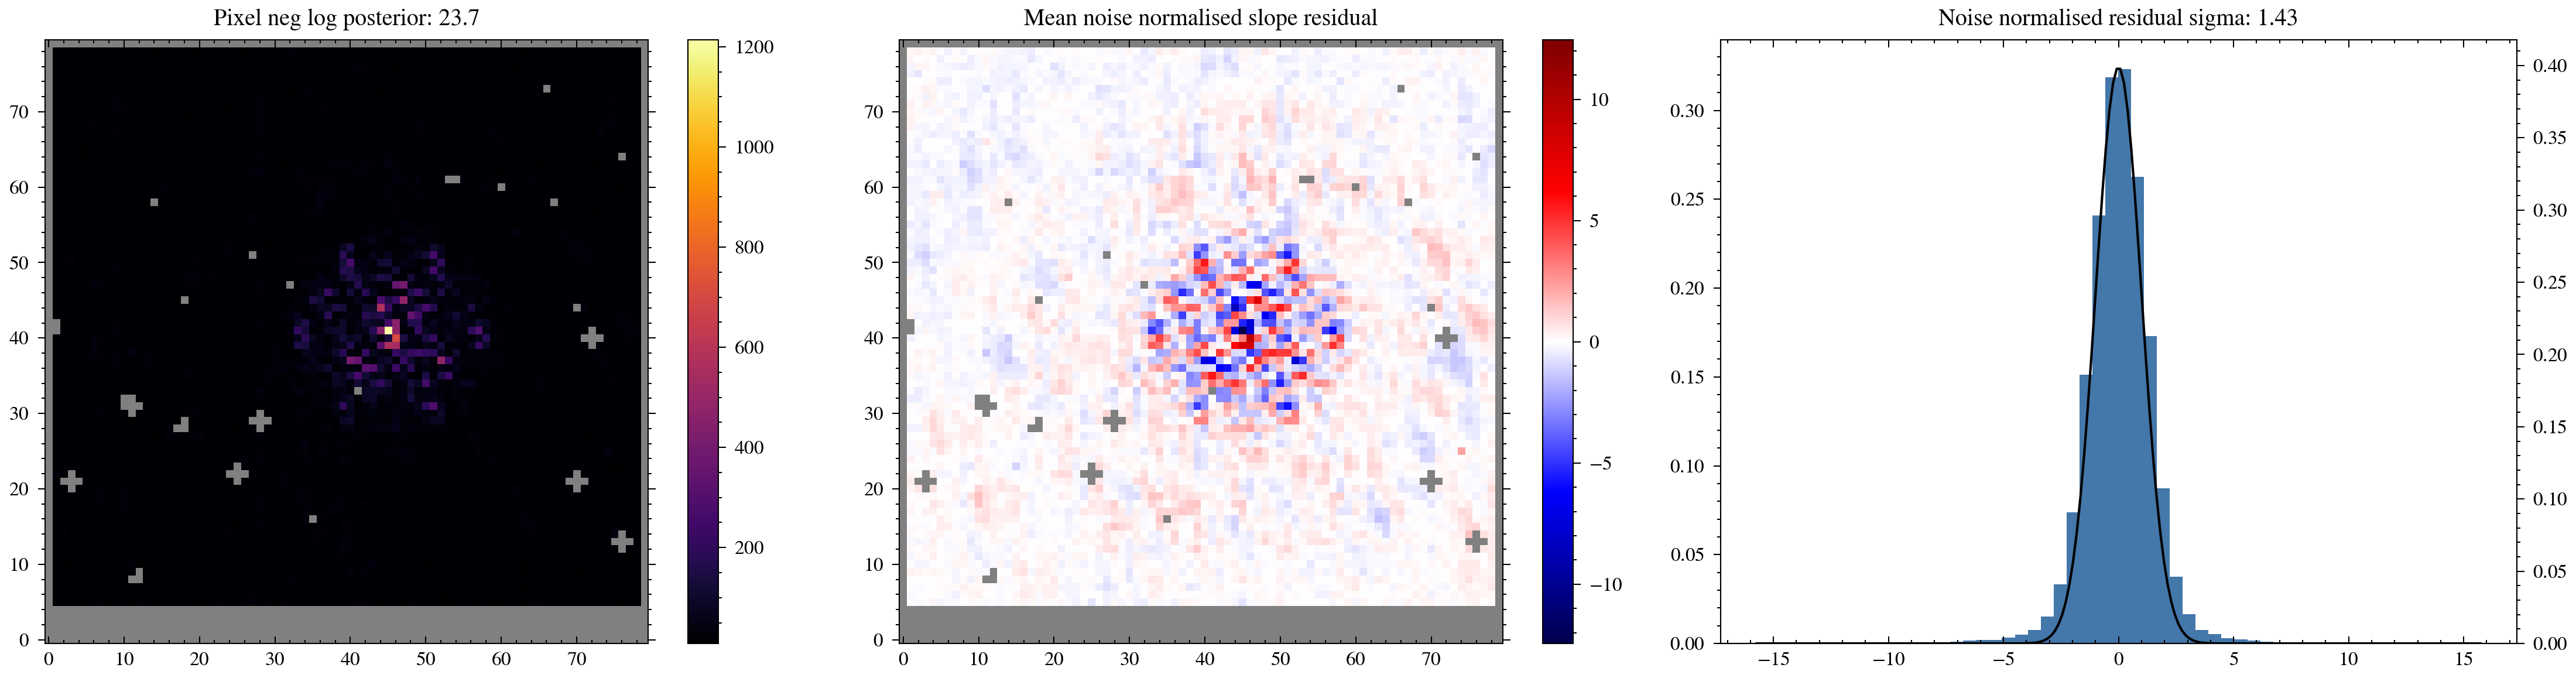

File 08330_002_06_03_10
Star V-EZ-Aqr
Filter F430M
nints 250
ngroups 16



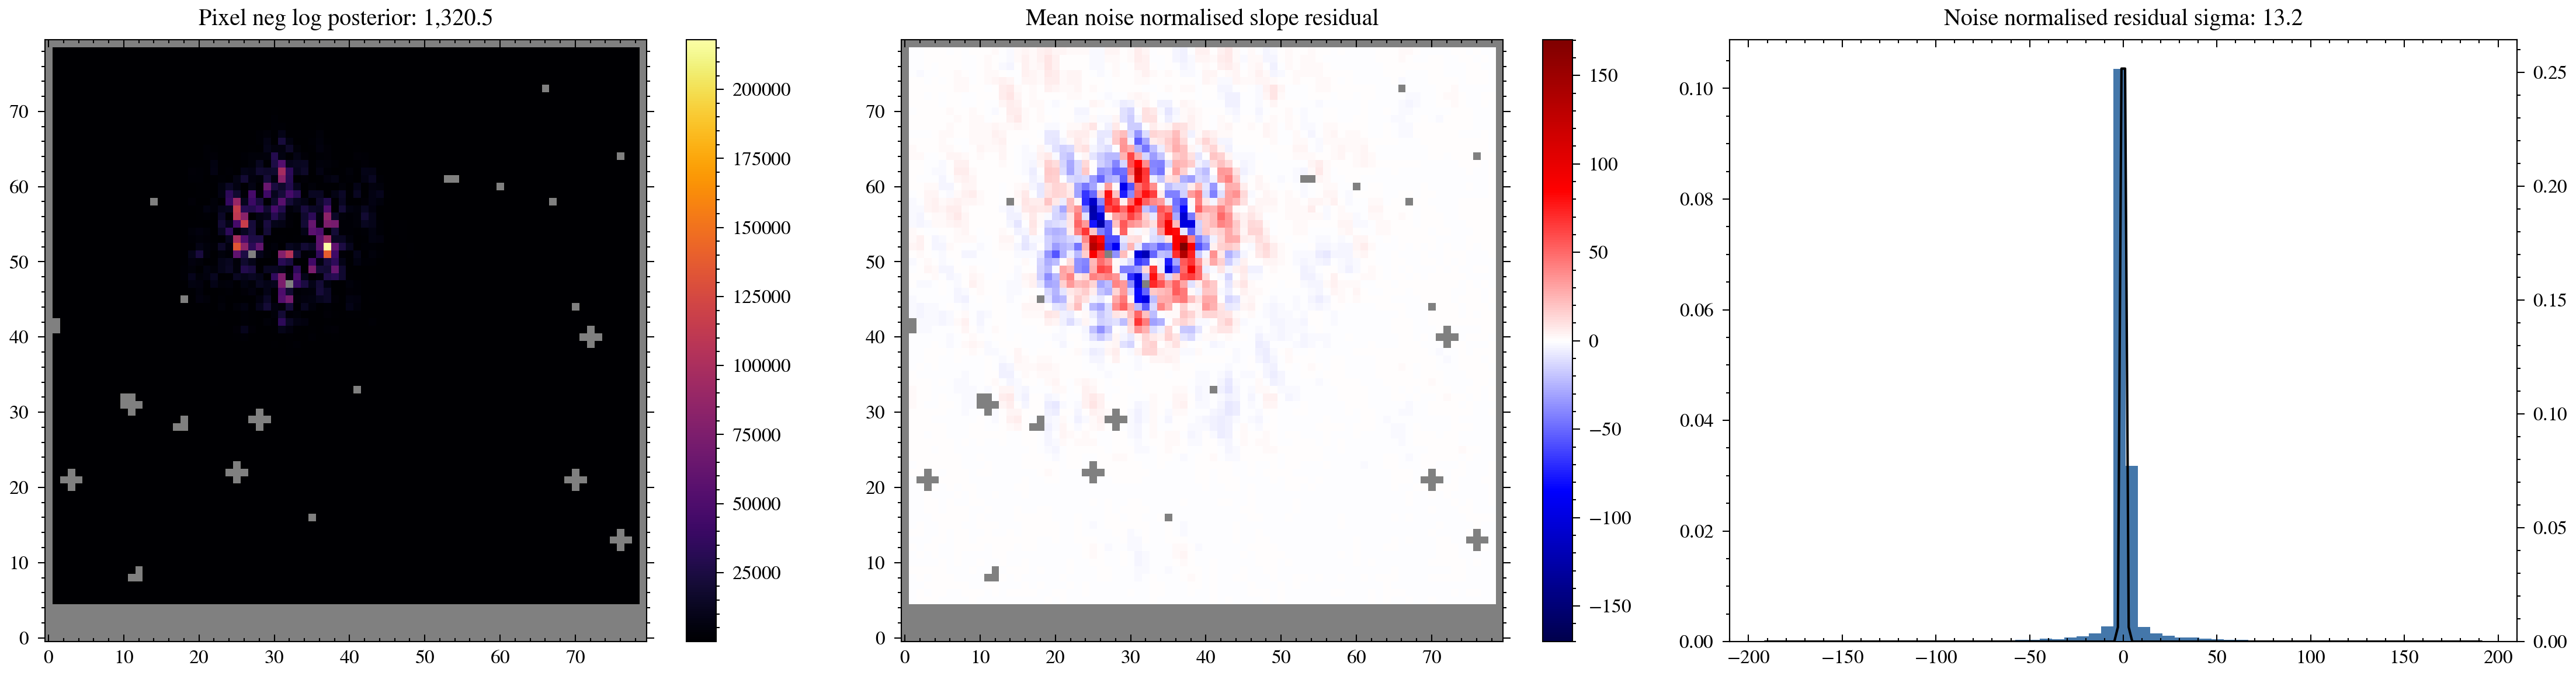

File 08330_002_06_03_4
Star V-EZ-Aqr
Filter F430M
nints 250
ngroups 16



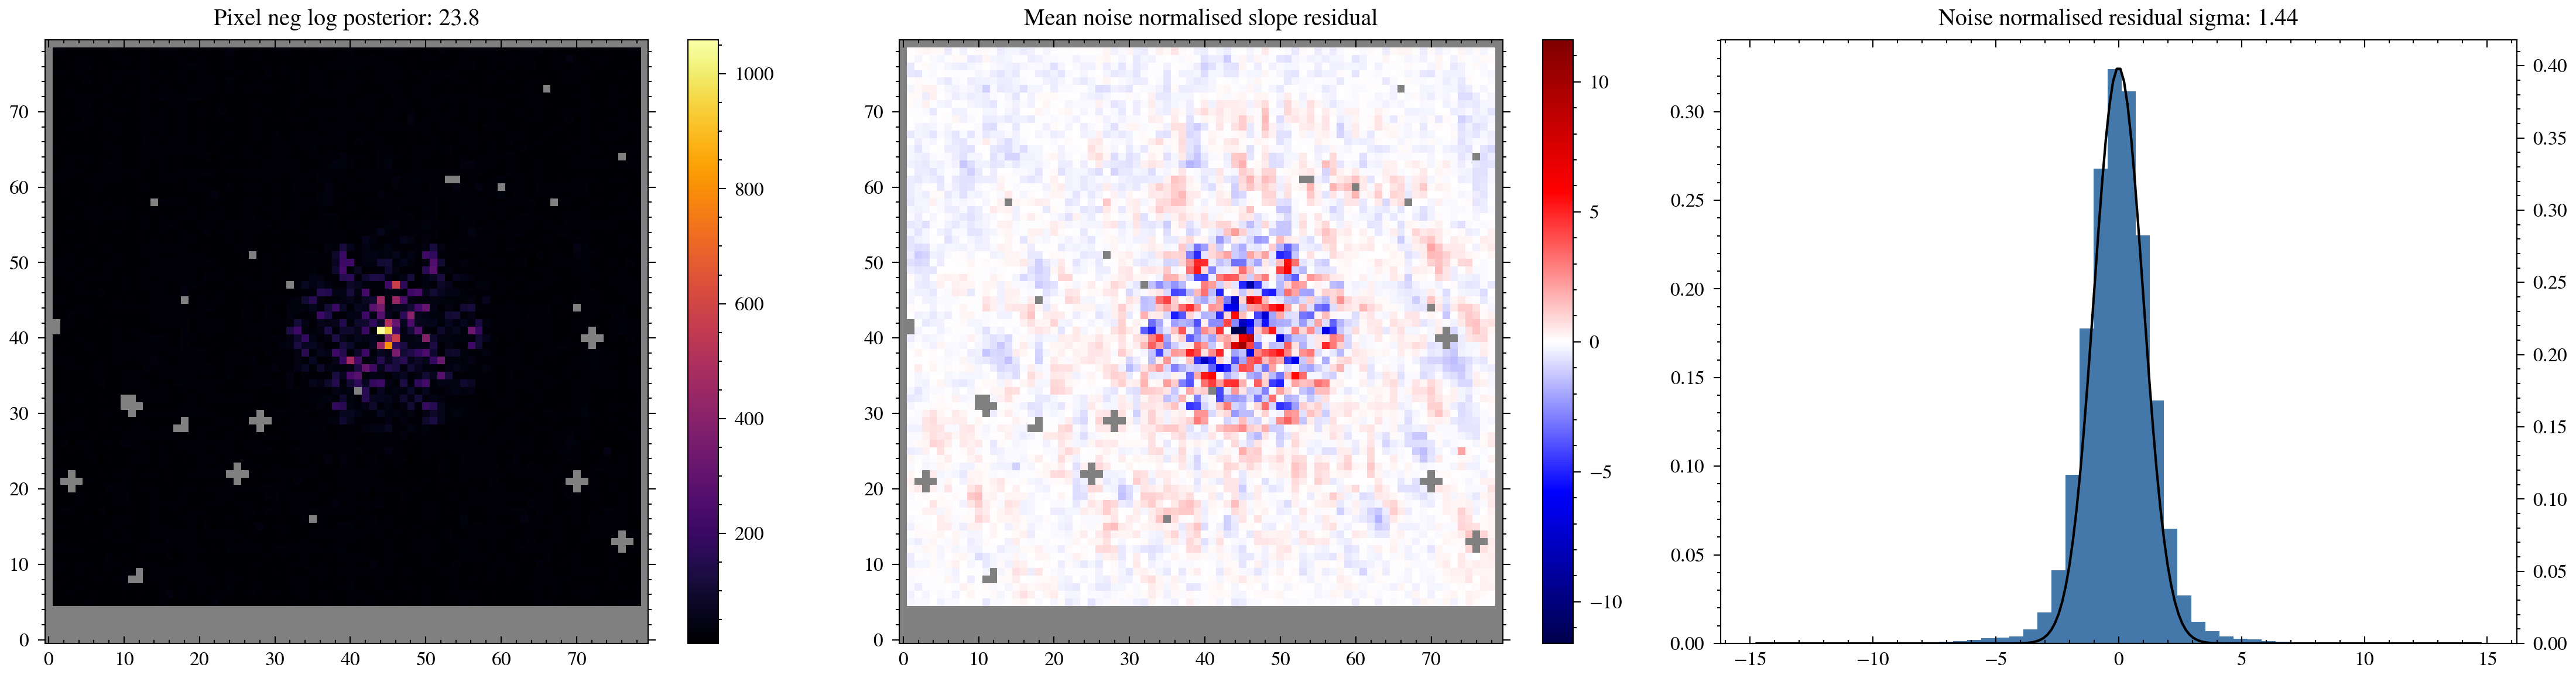

File 08330_002_06_03_9
Star V-EZ-Aqr
Filter F430M
nints 250
ngroups 16



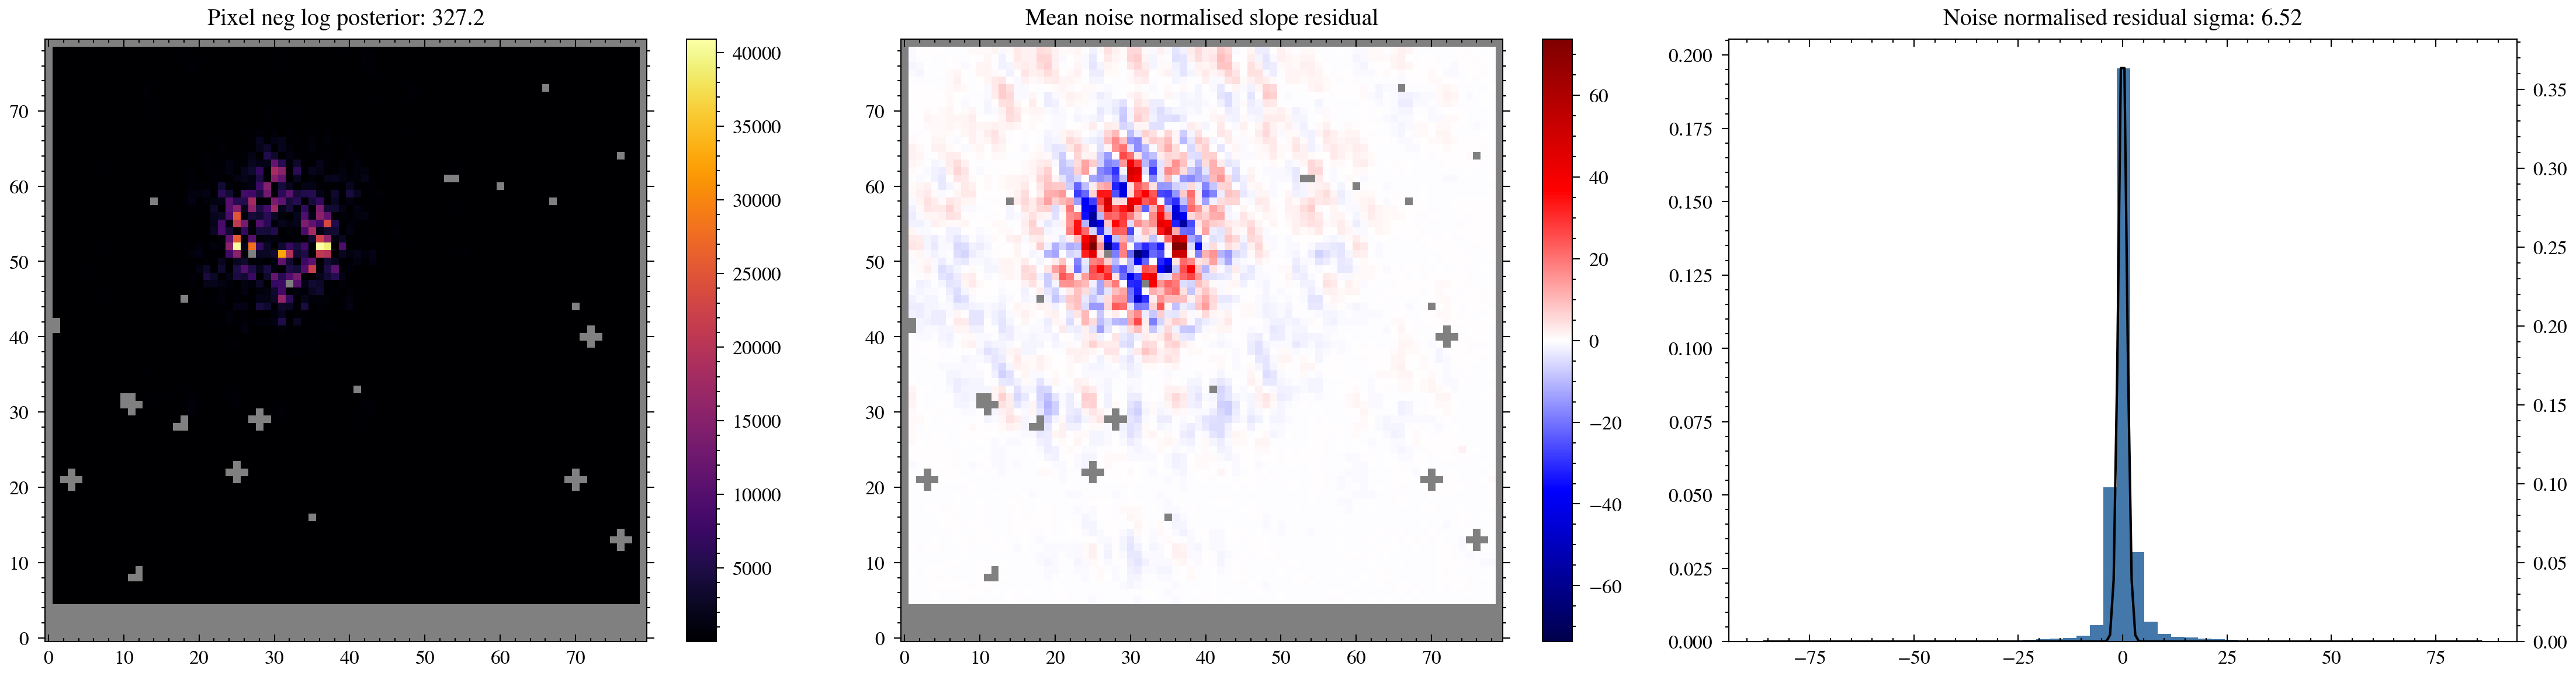

File 08330_002_04_03_5
Star V-EZ-Aqr
Filter F380M
nints 260
ngroups 11



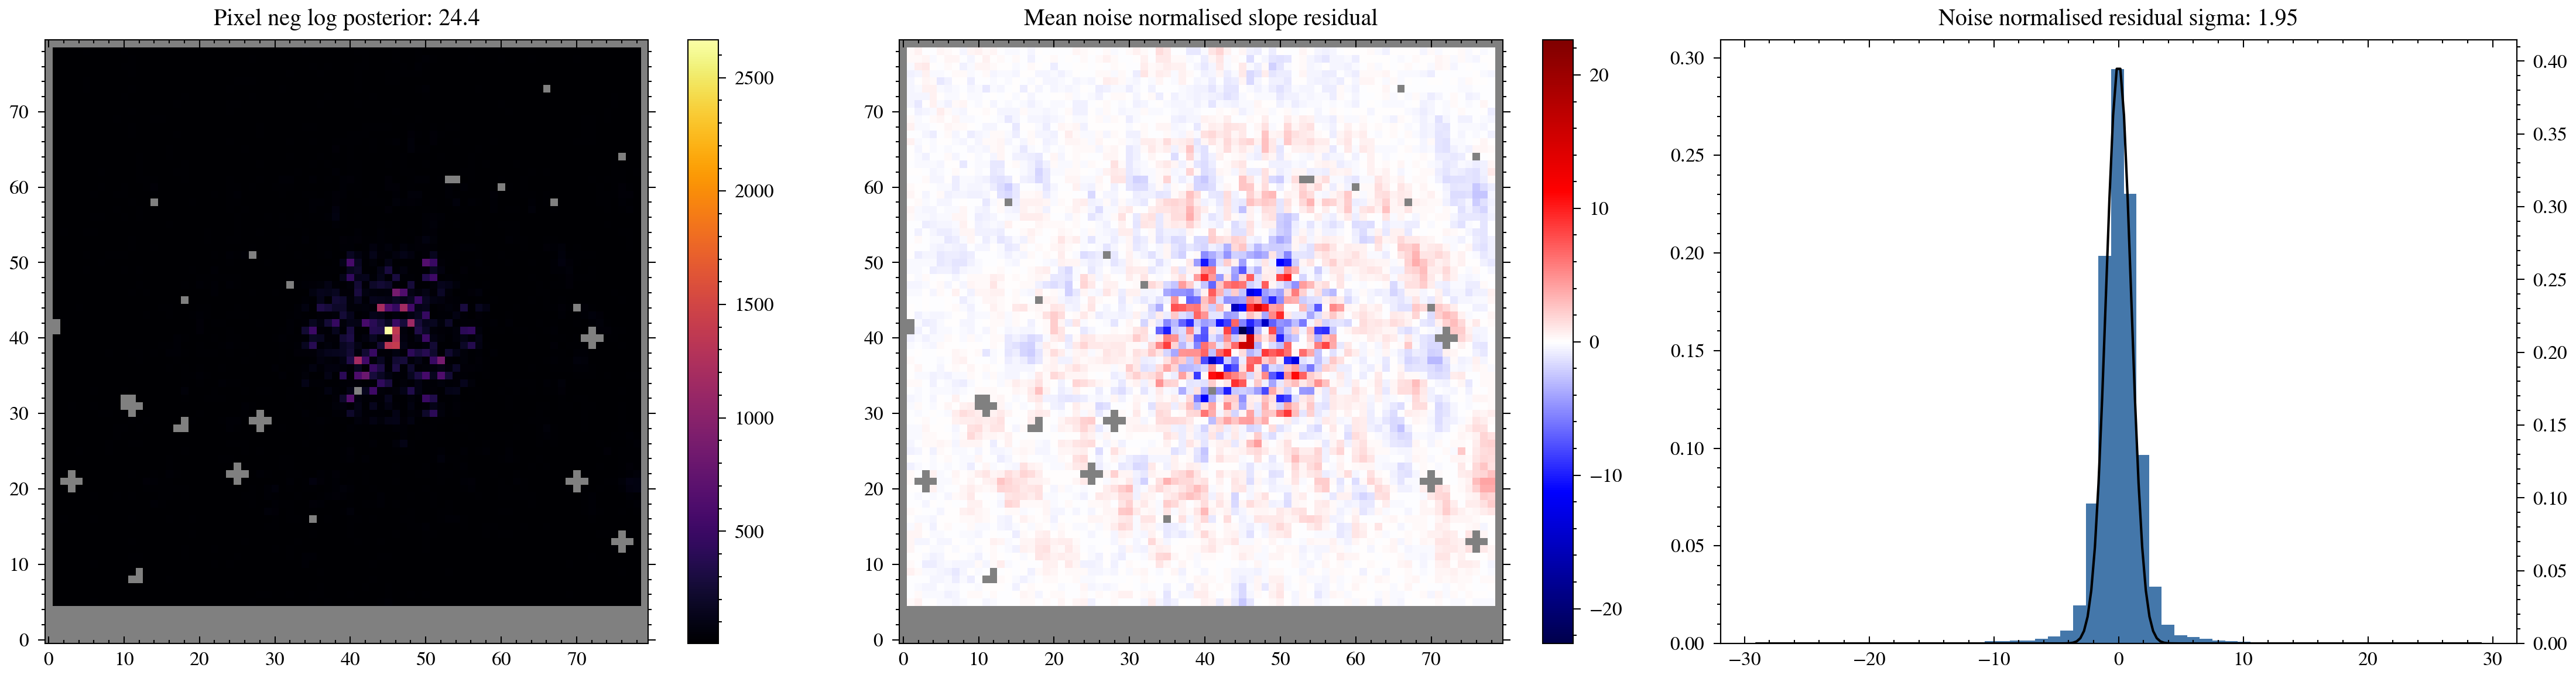

File 08330_002_04_03_10
Star V-EZ-Aqr
Filter F380M
nints 260
ngroups 11



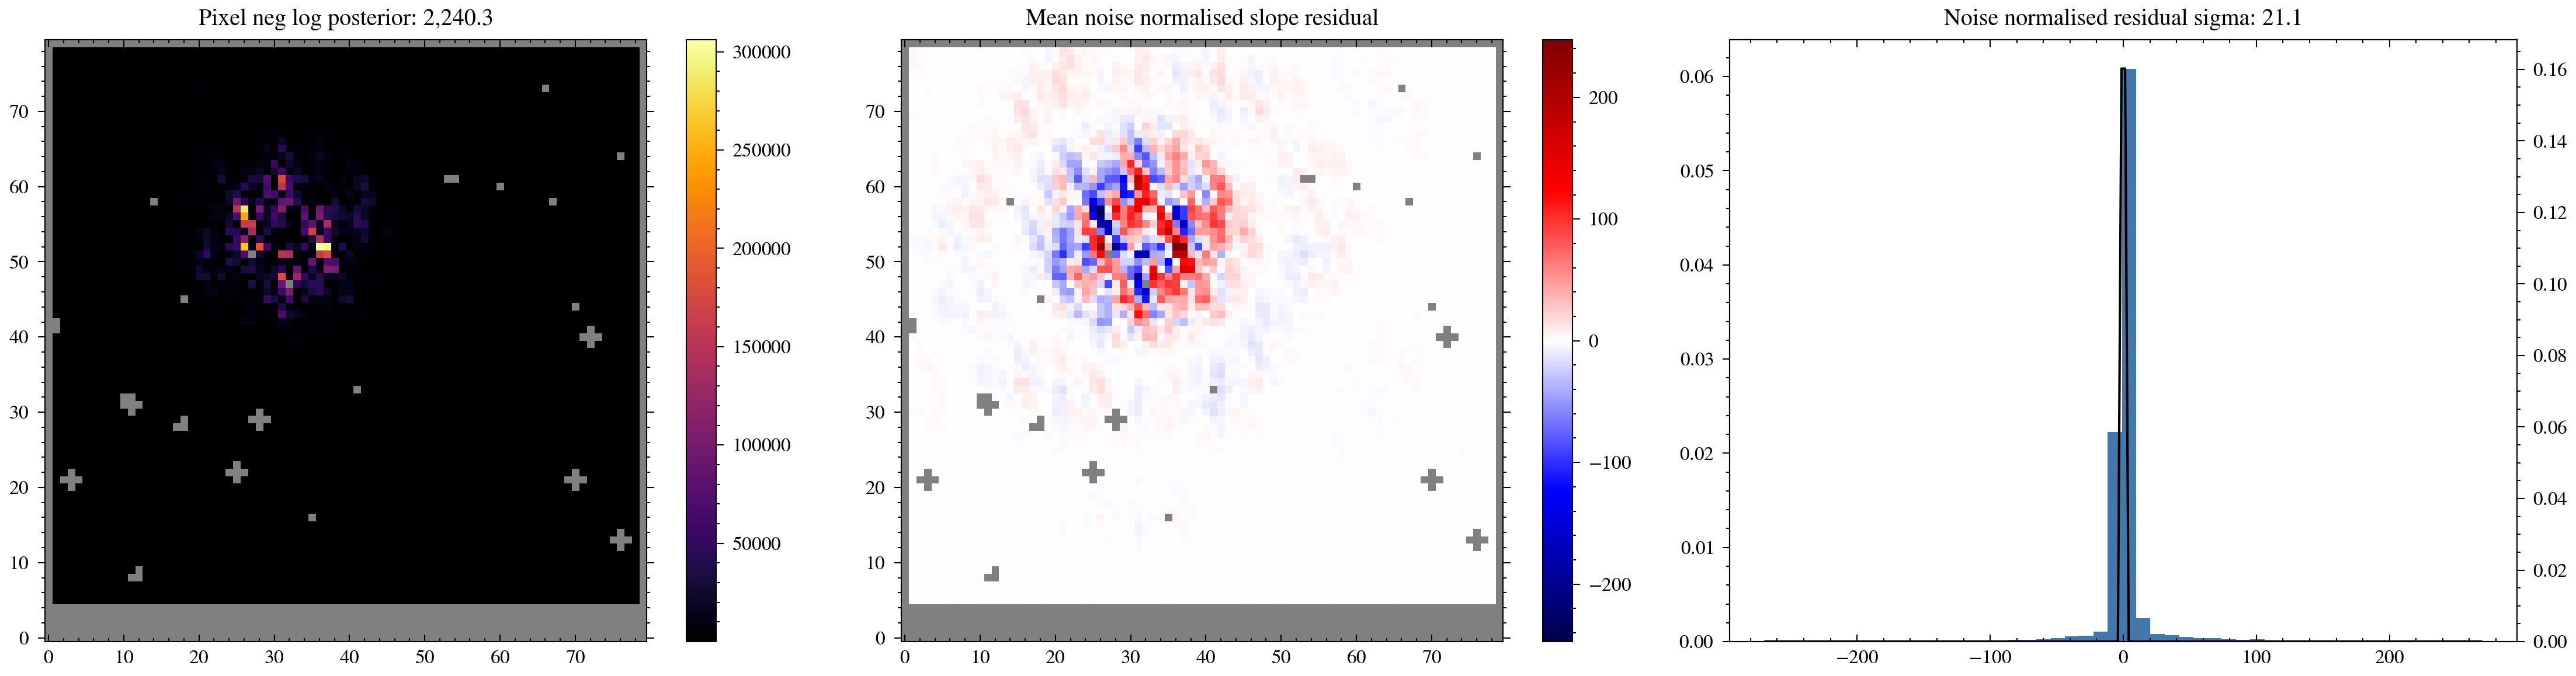

File 08330_002_04_03_4
Star V-EZ-Aqr
Filter F380M
nints 260
ngroups 11



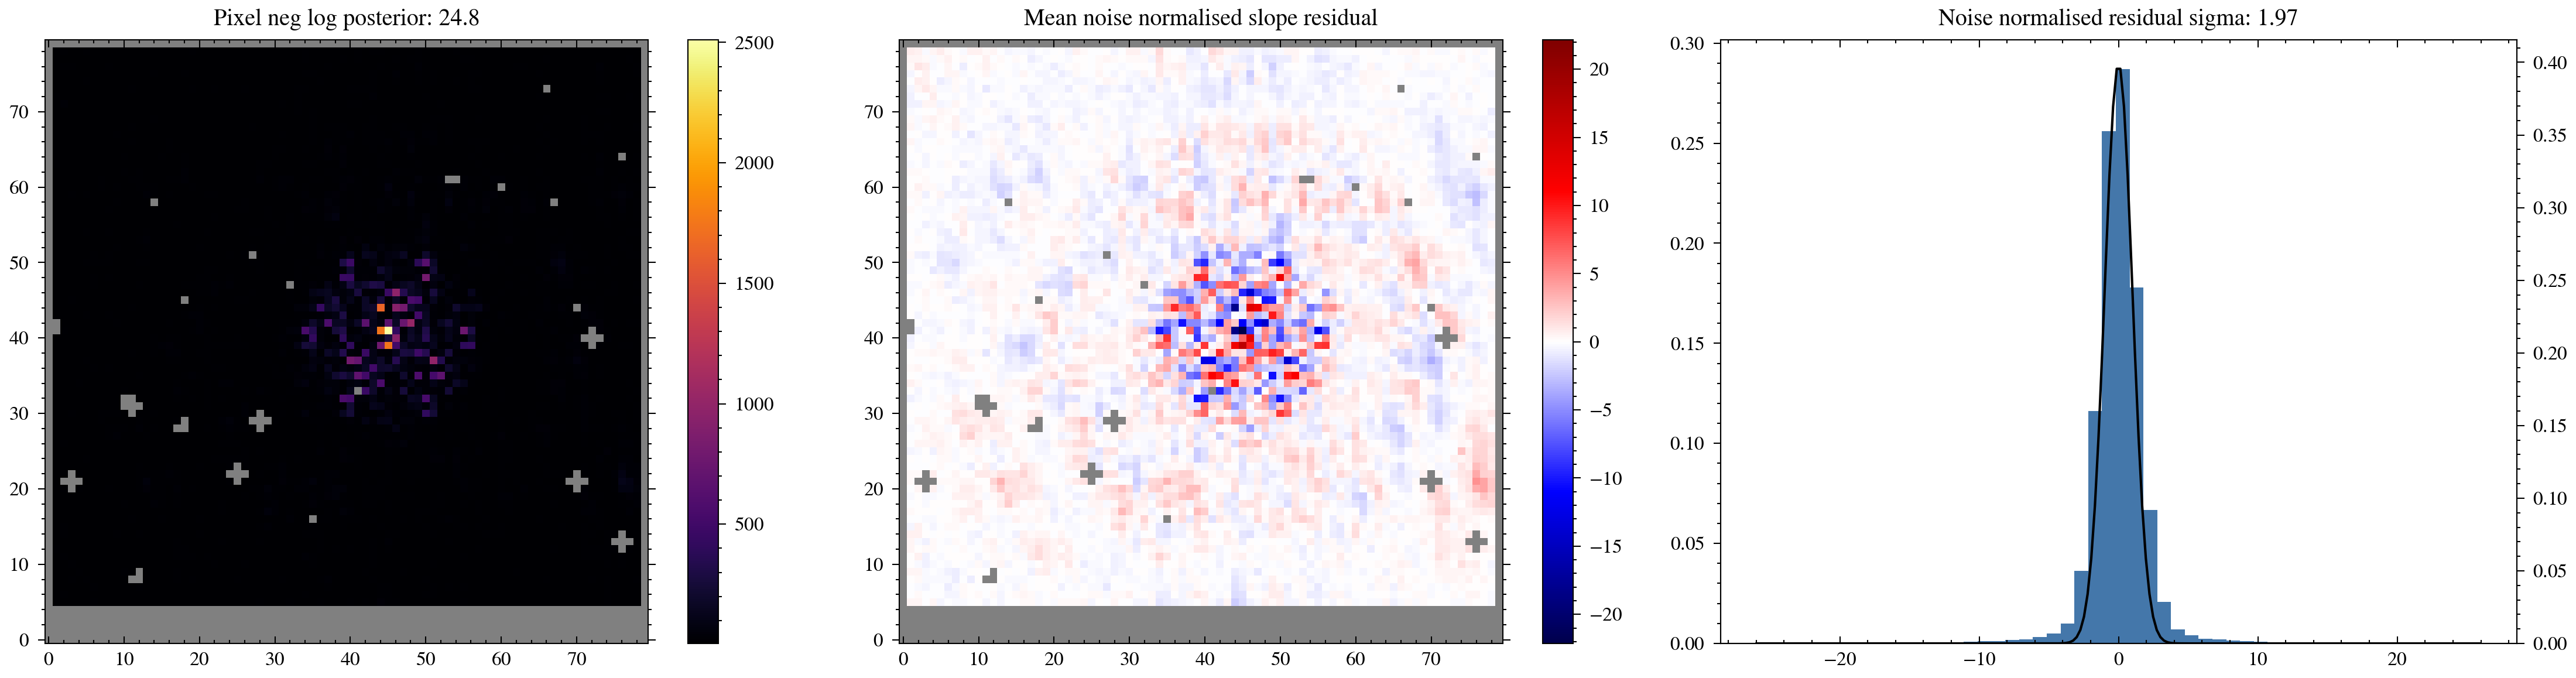

File 08330_002_04_03_9
Star V-EZ-Aqr
Filter F380M
nints 260
ngroups 11



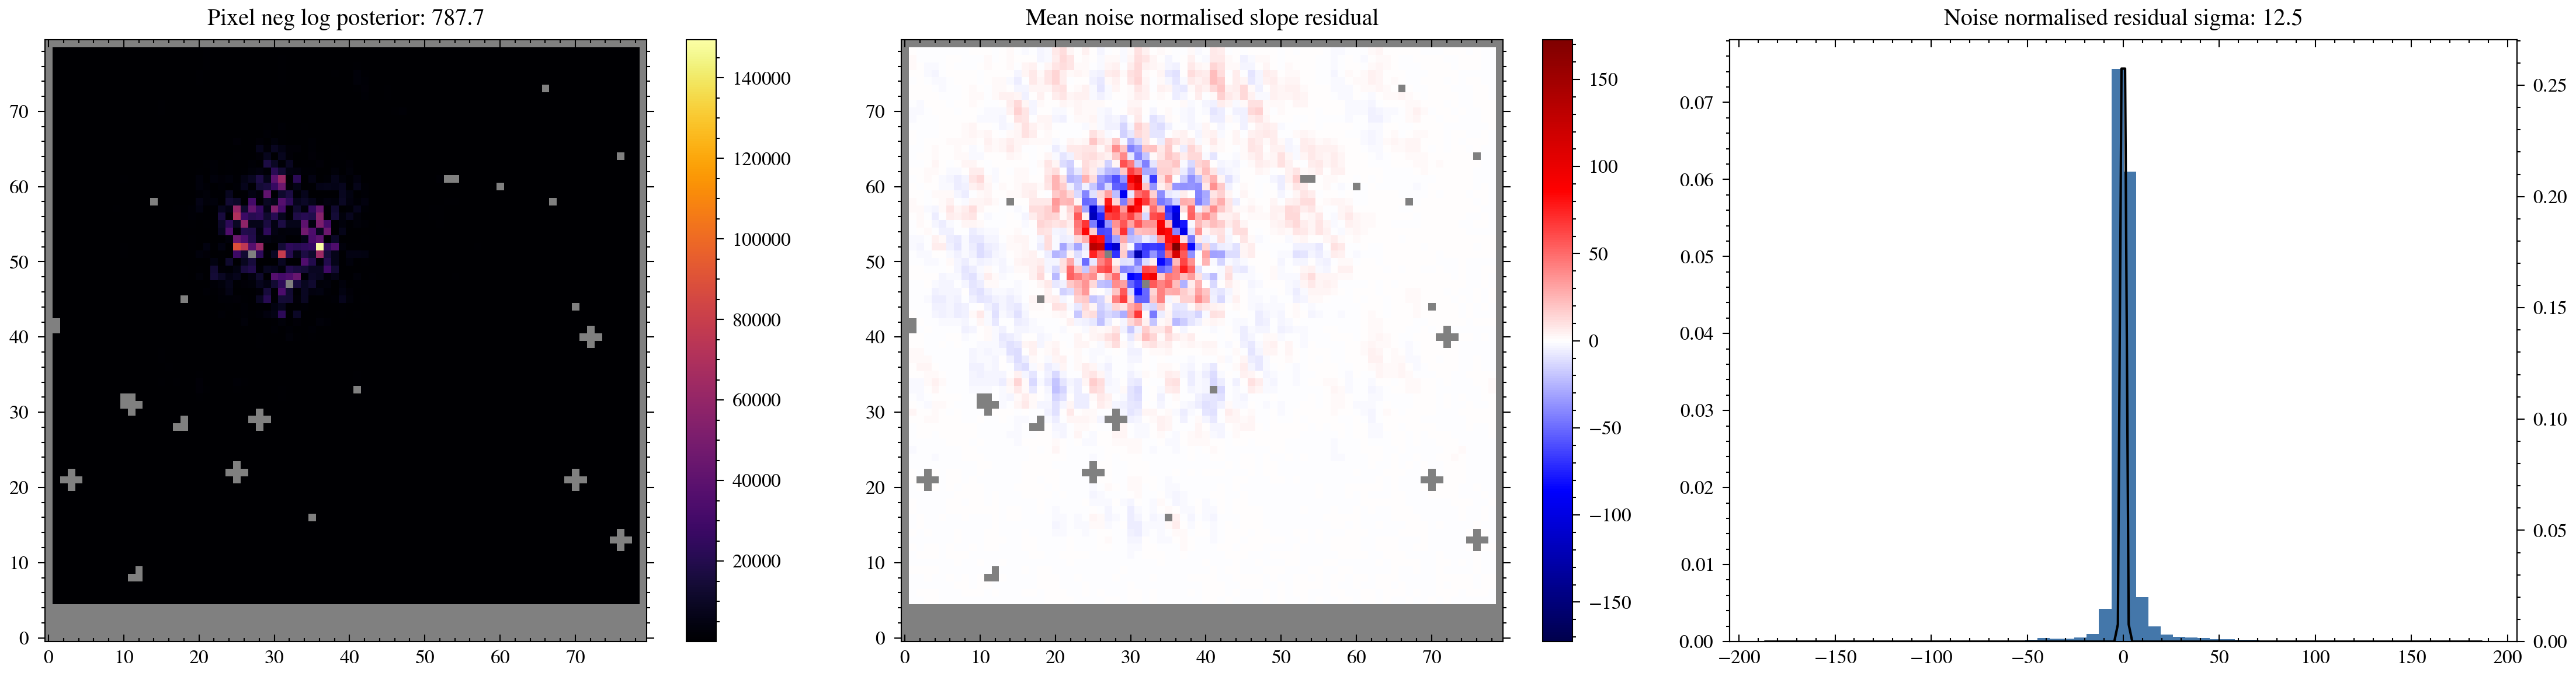

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 0 0 ... 0 0 1]
 [1 0 0 ... 0 0 1]
 [1 1 1 ... 1 1 1]]


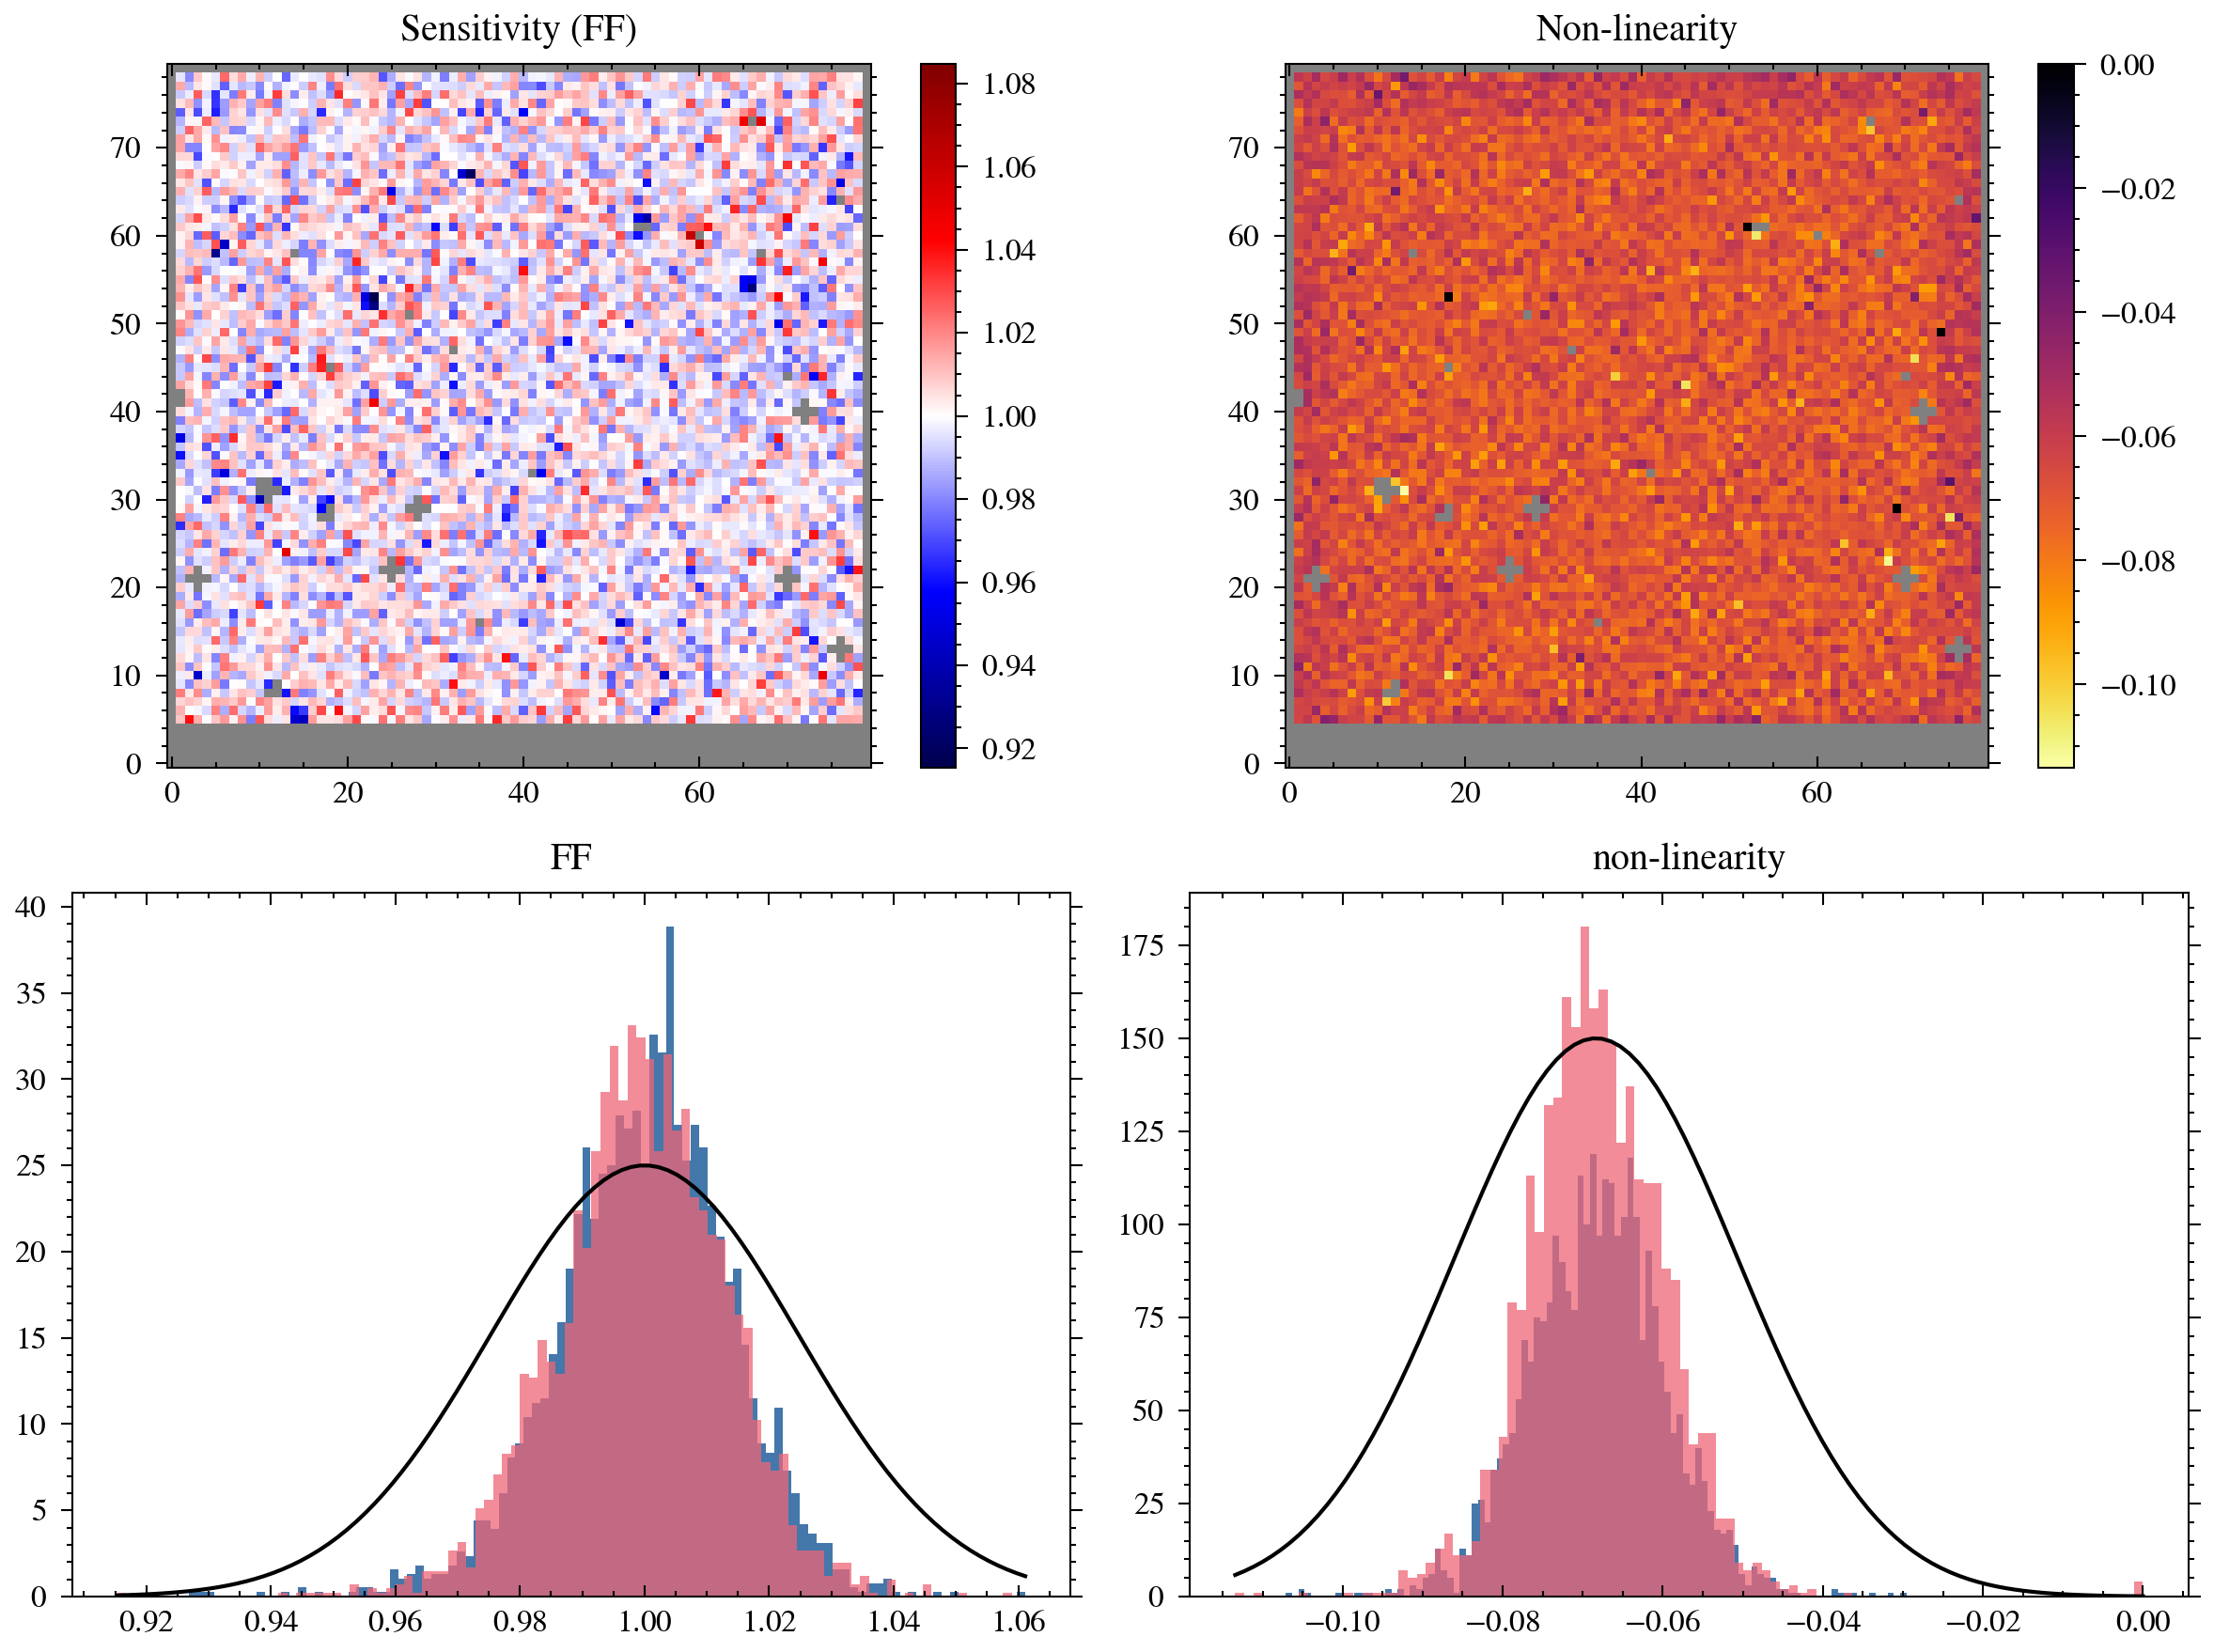

4481


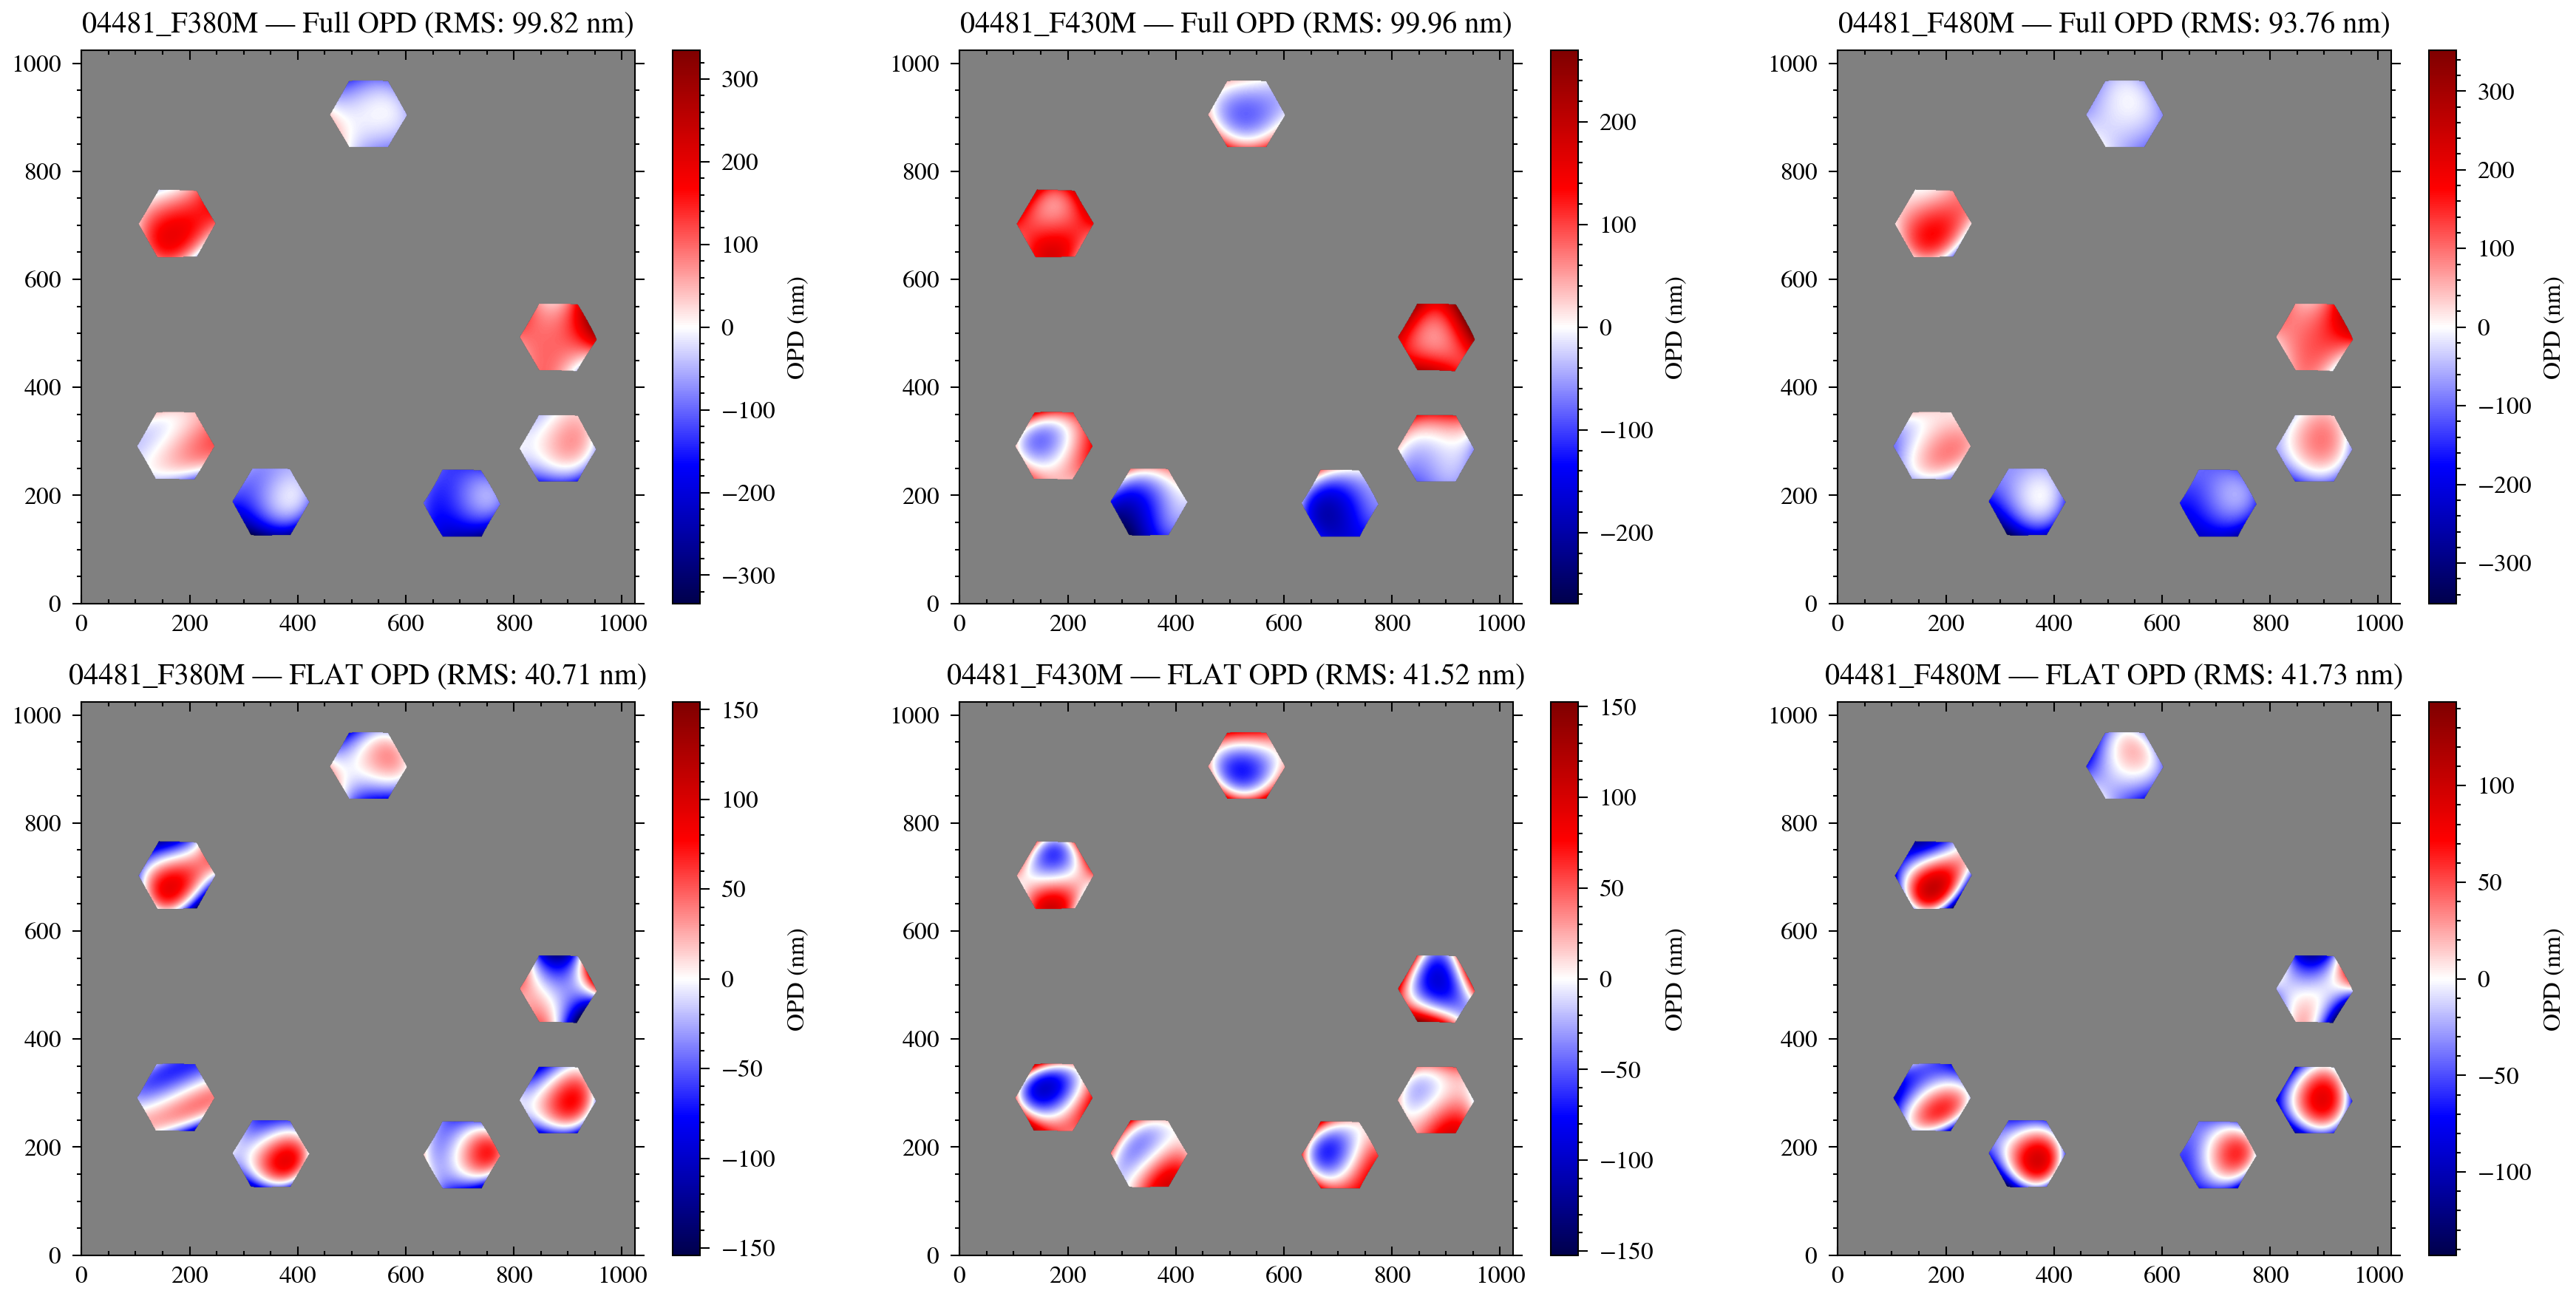

8330
Plotting wavefront failed: index 3 is out of bounds for axis 1 with size 3


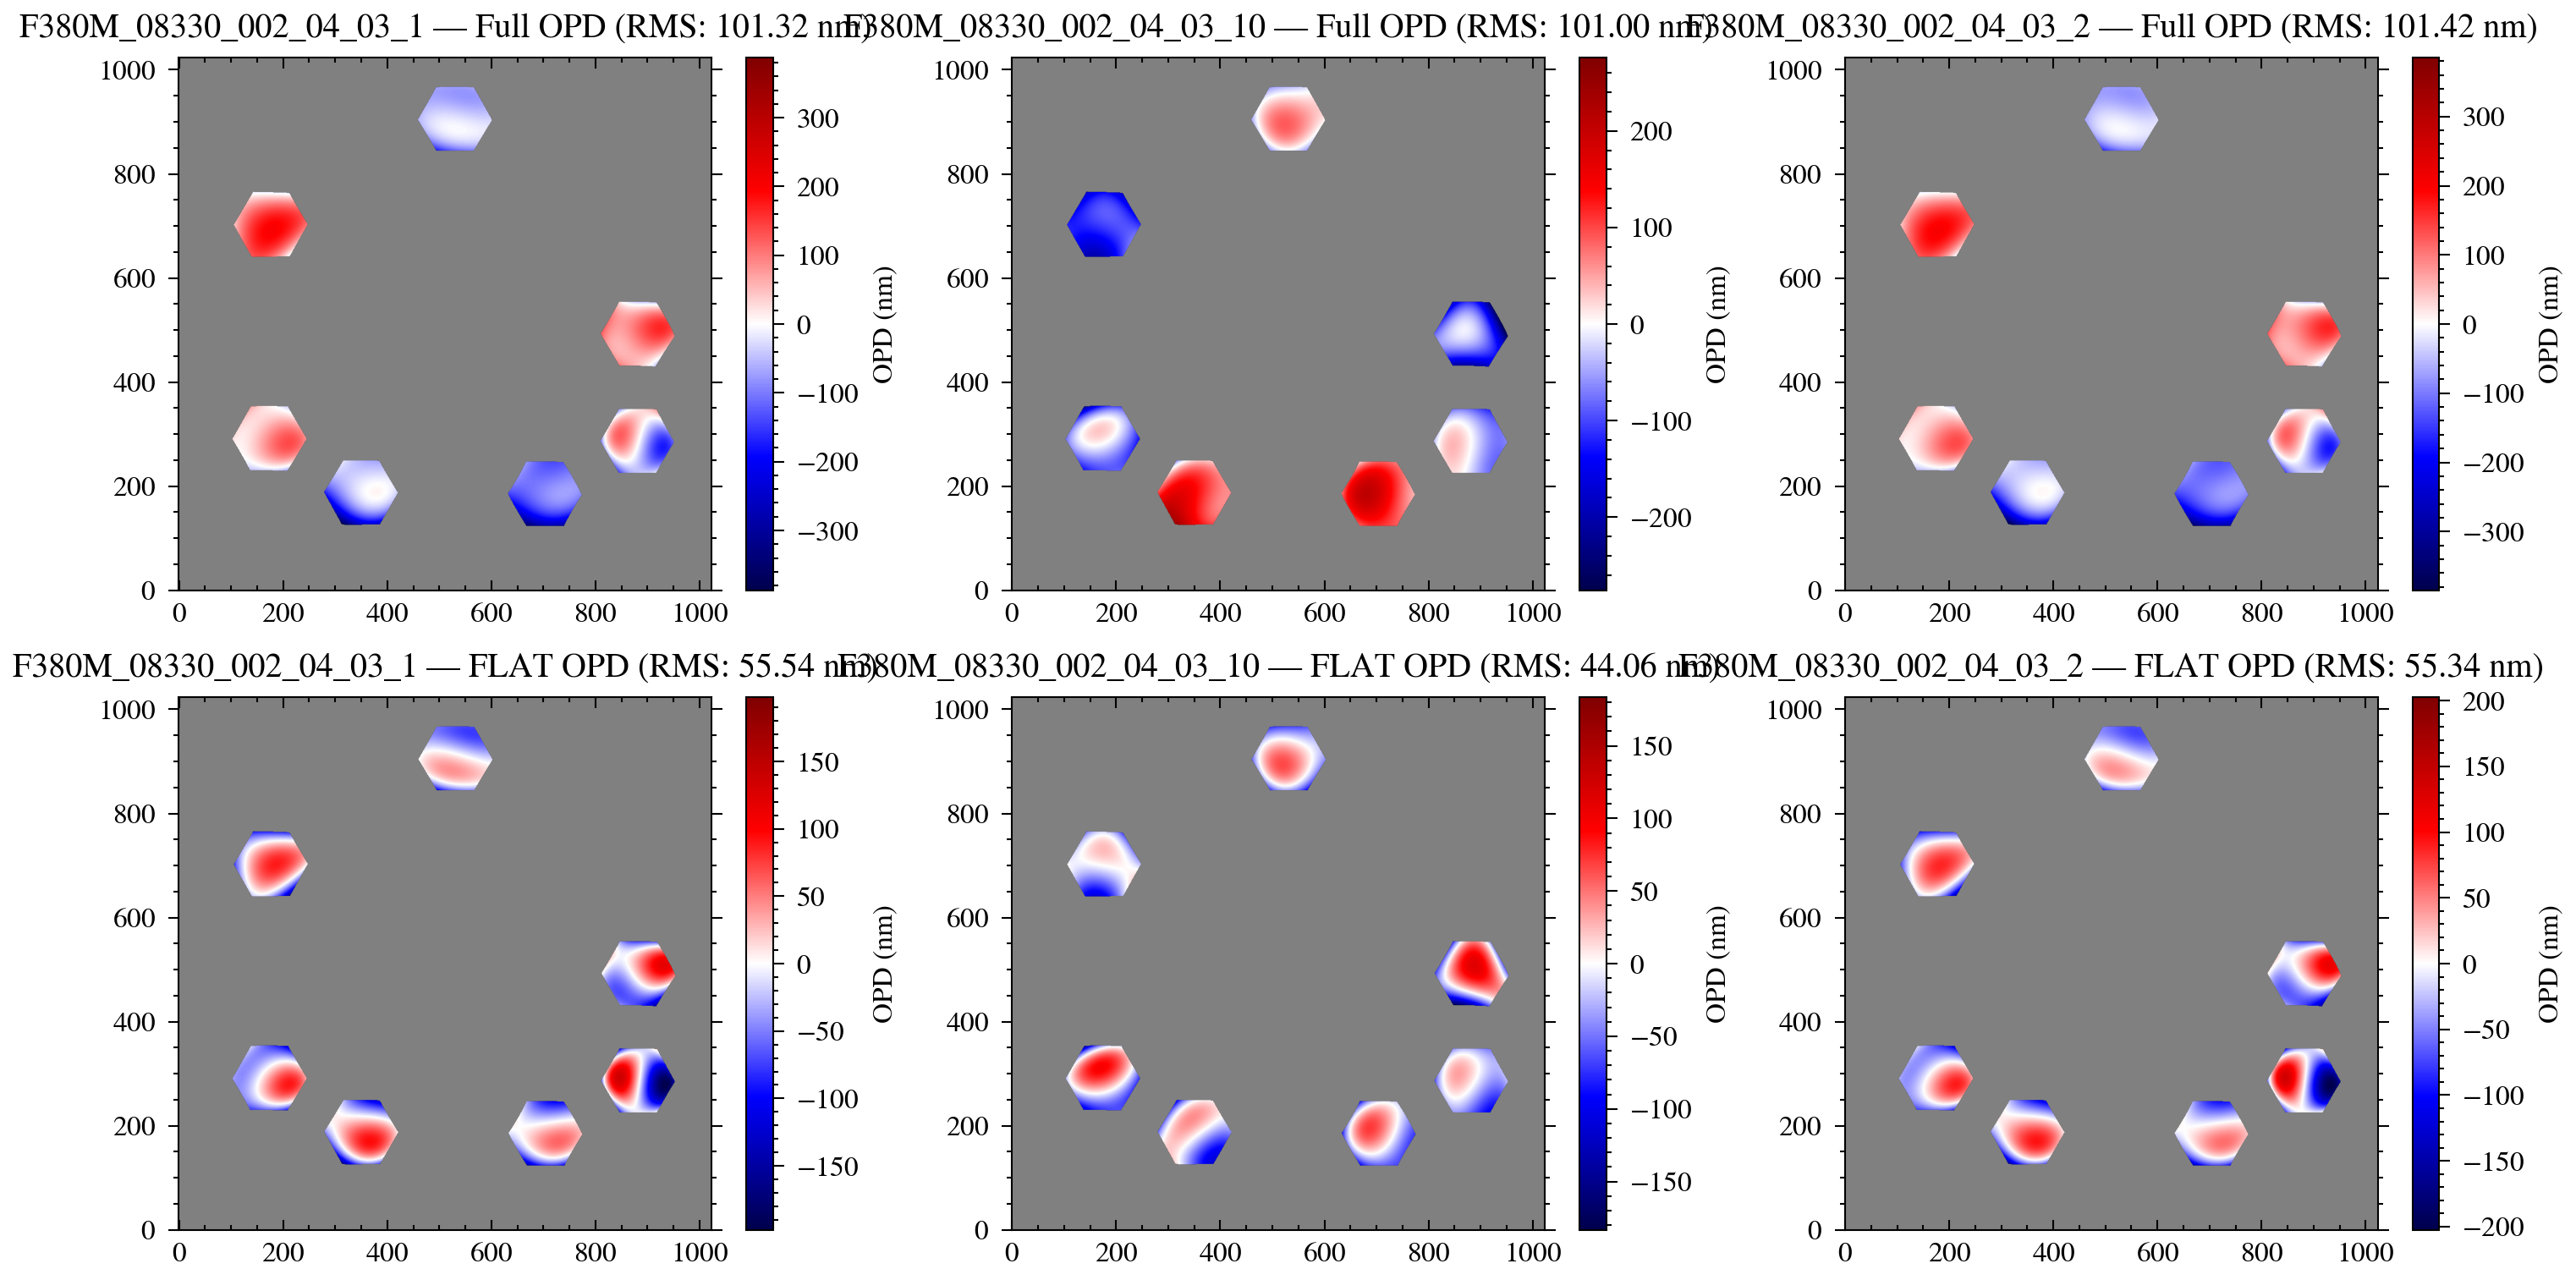

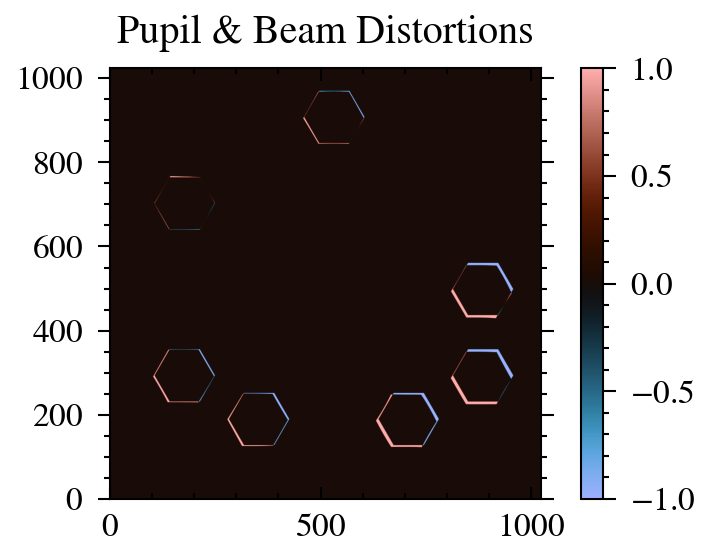

KeyboardInterrupt: 

In [19]:
from amigo.fitting import sgd, adam
import optax
from optax.schedules import linear_schedule

# Define the optimisers
optimisers = {
    "fluxes": sgd(1e-3, 0),
    "flat_coeffs": sgd(1e-3, 0),
    "positions": sgd(1e-3, 2),
    "aberrations": sgd(1e-4, 5),
    "pas": sgd(2e-4, 5),
    "separations": sgd(1e-4, 7),
    "contrasts": sgd(5e-4, 8),
    "nn_weights": sgd(1e-5, 0),  # lr applied with warm up
    "defocus": sgd(5e-4, 25),
    "distortion": sgd(5e-5, 30),
    "dark_current": sgd(2e-3, 35),
    "primary_beam": sgd(1e-5, 40),
    "sigma": sgd(1e-4, 50),  # start at 50th?
    "non_linearity": sgd(1e-4, 100),
    "FF": sgd(2e-5, 150),
    "spectra": sgd(1e-3, 20),
}

if not binary_flag:
    bin_ps = ["pas", "separations", "contrasts"]
    optimisers = {key: val for key, val in optimisers.items() if key not in bin_ps}

if not flat_flag:
    flat_ps = ["flat_coeffs"]
    optimisers = {key: val for key, val in optimisers.items() if key not in flat_ps}

if not val_flag:
    val_ps = ["spectra"]
    optimisers = {key: val for key, val in optimisers.items() if key not in val_ps}

if static_optics:
    dyn_ps = ["distortion", "primary_beam"]
    optimisers = {key: val for key, val in optimisers.items() if key not in dyn_ps}
    
        
print(optimisers.keys())
# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

batches = {}
if cal_flag:
    batches = {**batches, **cal_batch}
if val_flag:
    batches = {**batches, **val_batch}
if flat_flag:
    batches = {**batches, **flat_batch}

summarise_kwargs = {
    "val_flag": val_flag,
    "flat_flag": flat_flag,
    "binary_flag": binary_flag,
    "save_flag": save_flag,
    "cal_flag": cal_flag,
    "static_optics": static_optics,
    "cal_exposures": cal_exposures,
    "val_exposures": val_exposures,
    "flat_exposures": flat_exposures,
    "calpsf_exposures": calpsf_exposures,
    "calbin_exposures": calbin_exposures,
    "badpix": badpix,
    "n_batch": n_batch,
    "optimisers": optimisers,
    "amigo_files_path": amigo_files_path,
}

common_trainer_kwargs = {
    "model": model,
    "optimisers": optimisers,
    "epochs": epochs,
    "batches": batches,
    "args": args,
    "summarise_kwargs": summarise_kwargs,
}

if val_flag:
    if "nn_weights" in optimisers.keys():
        common_trainer_kwargs["batched_params"] = ["nn_weights"]
    else:
        common_trainer_kwargs["batched_params"] = []

val_trainer_kwargs = {
    "validators": val_batch,
    "validator_params": ["positions", "fluxes", "aberrations", "spectra"]
    }

trainer_kwargs = {**common_trainer_kwargs, **val_trainer_kwargs} if val_flag else common_trainer_kwargs

# with jax.disable_jit():
result = trainer.train(**trainer_kwargs)

Plotting the results of that fit!

# Saving results

In [ ]:
summarise_fn(result, save_path, **summarise_kwargs)